In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\statslab\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_excel(r"C:\Users\statslab\Downloads\DigiHack Dataset.xlsx", sheet_name = 'Data')

In [4]:
df.head()

,ID,Age,Customer_type,Gross_income,Net_income,SEX,Type_of_industry,Marital_Status,Months_in_city,Months_in_current_job,...,ACCOUNT_12,ACCOUNT_13,ACCOUNT_14,ACCOUNT_15,ACCOUNT_16,ACCOUNT_17,ACCOUNT_18,ACCOUNT_19,ACCOUNT_20,ACCOUNT_21
0,1,42.0,SELF EMPLOYED,91666.67,91666.6667,MALE,CONSTRUCTION,MARRIED,0.0,96,...,13,0,5,3,0,3,1837374,0,1837374,1657
1,1,42.0,SELF EMPLOYED,91666.67,91666.6667,MALE,CONSTRUCTION,MARRIED,0.0,96,...,13,0,5,3,0,3,1837374,0,1837374,1657
2,2,38.0,SALARIED,150000.00,30000.0000,FEMALE,OTHERS,MARRIED,0.0,120,...,4,0,3,2,0,2,10380,0,10380,124
3,2,38.0,SALARIED,150000.00,30000.0000,FEMALE,OTHERS,MARRIED,0.0,120,...,4,0,3,2,0,2,10380,0,10380,124
4,3,36.0,SELF EMPLOYED,188183.33,188183.3333,MALE,OTHERS,MARRIED,0.0,0,...,30,2,21,8,1,7,3445241,1536325,1908916,2534


In [5]:
df.shape

(3980, 35)

### 1. Data Pre-Processing

Check for Duplicates :
* at Columns level
* at ID level

In [6]:
df.columns.duplicated()
df['ID'].duplicated().sum()

86

Data - types for all variables

In [7]:
df.dtypes

ID                         int64
Age                      float64
Customer_type             object
Gross_income             float64
Net_income               float64
SEX                       object
Type_of_industry          object
Marital_Status            object
Months_in_city           float64
Months_in_current_job      int64
Org_Type                  object
Bank_balance             float64
Debt_ratio               float64
Target                     int64
ENQ_1                      int64
ENQ_2                      int64
ENQ_3                      int64
ENQ_4                      int64
ENQ_5                      int64
ENQ_6                      int64
ENQ_7                      int64
ENQ_8                      int64
ACCOUNT_9                  int64
ACCOUNT_10                 int64
ACCOUNT_11                 int64
ACCOUNT_12                 int64
ACCOUNT_13                 int64
ACCOUNT_14                 int64
ACCOUNT_15                 int64
ACCOUNT_16                 int64
ACCOUNT_17

Check for Missing values 

In [8]:
df.isnull().sum()

ID                         0
Age                        1
Customer_type              0
Gross_income               0
Net_income                 0
SEX                        4
Type_of_industry           5
Marital_Status             4
Months_in_city             4
Months_in_current_job      0
Org_Type                   0
Bank_balance             636
Debt_ratio                 0
Target                     0
ENQ_1                      0
ENQ_2                      0
ENQ_3                      0
ENQ_4                      0
ENQ_5                      0
ENQ_6                      0
ENQ_7                      0
ENQ_8                      0
ACCOUNT_9                  0
ACCOUNT_10                 0
ACCOUNT_11                 0
ACCOUNT_12                 0
ACCOUNT_13                 0
ACCOUNT_14                 0
ACCOUNT_15                 0
ACCOUNT_16                 0
ACCOUNT_17                 0
ACCOUNT_18                 0
ACCOUNT_19                 0
ACCOUNT_20                 0
ACCOUNT_21    

In [9]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

num_cols, cat_cols

(Index(['ID', 'Age', 'Gross_income', 'Net_income', 'Months_in_city',
        'Months_in_current_job', 'Bank_balance', 'Debt_ratio', 'Target',
        'ENQ_1', 'ENQ_2', 'ENQ_3', 'ENQ_4', 'ENQ_5', 'ENQ_6', 'ENQ_7', 'ENQ_8',
        'ACCOUNT_9', 'ACCOUNT_10', 'ACCOUNT_11', 'ACCOUNT_12', 'ACCOUNT_13',
        'ACCOUNT_14', 'ACCOUNT_15', 'ACCOUNT_16', 'ACCOUNT_17', 'ACCOUNT_18',
        'ACCOUNT_19', 'ACCOUNT_20', 'ACCOUNT_21'],
       dtype='object'),
 Index(['Customer_type', 'SEX', 'Type_of_industry', 'Marital_Status',
        'Org_Type'],
       dtype='object'))

Univariate distribution for Numeric variables & frequency distribution for Categorical variables

In [10]:
df[num_cols].describe()

,ID,Age,Gross_income,Net_income,Months_in_city,Months_in_current_job,Bank_balance,Debt_ratio,Target,ENQ_1,...,ACCOUNT_12,ACCOUNT_13,ACCOUNT_14,ACCOUNT_15,ACCOUNT_16,ACCOUNT_17,ACCOUNT_18,ACCOUNT_19,ACCOUNT_20,ACCOUNT_21
count,3980.000000,3979.000000,3.980000e+03,3.980000e+03,3976.000000,3.980000e+03,3.344000e+03,3.980000e+03,3980.000000,3980.000000,...,3980.000000,3980.000000,3980.000000,3980.000000,3980.000000,3980.000000,3.980000e+03,3.980000e+03,3.980000e+03,3980.000000
mean,1906.401759,38.353606,8.728823e+04,7.962038e+04,174.176811,1.030009e+03,1.426380e+05,8.693371e+03,0.077387,183.677638,...,5.923367,0.671608,3.074372,2.422111,0.487940,1.374121,1.660992e+06,1.394830e+06,2.661650e+05,621.135176
std,1146.057937,8.387179,4.493592e+05,4.201051e+05,172.142957,5.469251e+04,1.130916e+06,5.733927e+04,0.267238,395.595808,...,7.880766,1.362053,4.286193,2.876832,0.905766,1.901041,7.601363e+06,7.102065e+06,1.502936e+06,702.175916
min,1.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,-2.965788e+06,0.000000e+00,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,909.750000,32.000000,2.100000e+04,2.386356e+04,0.000000,4.000000e+00,9.428250e+03,3.000000e-01,0.000000,9.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.434575e+04,0.000000e+00,0.000000e+00,188.750000
50%,1904.500000,38.000000,3.305250e+04,3.533350e+04,120.000000,4.800000e+01,2.543200e+04,4.700000e-01,0.000000,38.000000,...,3.000000,0.000000,2.000000,2.000000,0.000000,1.000000,2.002835e+05,3.522800e+04,4.444000e+03,430.500000
75%,2899.250000,44.000000,5.145510e+04,5.442150e+04,300.000000,1.200000e+02,7.204150e+04,5.900000e-01,0.000000,156.000000,...,7.000000,1.000000,4.000000,3.000000,1.000000,2.000000,1.072006e+06,8.727002e+05,1.066508e+05,792.500000
max,3895.000000,71.000000,1.466248e+07,1.466248e+07,744.000000,3.441168e+06,4.667487e+07,1.311486e+06,1.000000,4492.000000,...,109.000000,24.000000,37.000000,64.000000,15.000000,18.000000,2.485371e+08,2.415865e+08,3.422155e+07,5311.000000


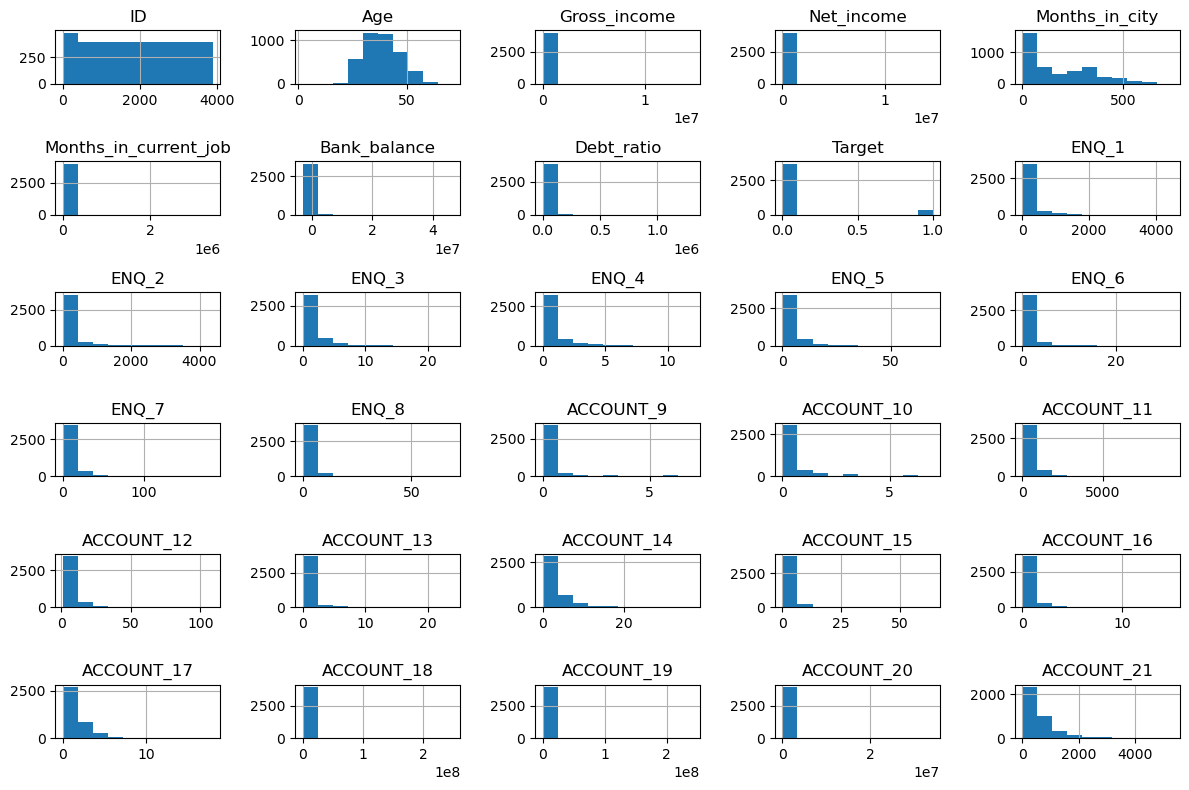

In [11]:
df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [12]:
for col in cat_cols:
    print(f"\nFrequency distribution for {col}")
    print(df[col].value_counts())


Frequency distribution for Customer_type
Customer_type
SELF EMPLOYED    2256
SALARIED         1701
NON EARNING        23
Name: count, dtype: int64

Frequency distribution for SEX
SEX
MALE      3342
FEMALE     634
Name: count, dtype: int64

Frequency distribution for Type_of_industry
Type_of_industry
OTHERS                                     3272
TEXTILES                                     67
CONSTRUCTION                                 53
FOOD PRODUCTS                                41
IT AND COMMUNICATION                         38
                                           ... 
PHARMACEUTICALS FORMULATIONS                  1
PLYWOOD AND LAMINATES                         1
TEXTILE WEAVING KNITTING AND PROCESSING       1
IT HARDWARE                                   1
CERAMIC TILES AND SANITARY WARE               1
Name: count, Length: 80, dtype: int64

Frequency distribution for Marital_Status
Marital_Status
MARRIED      3542
SINGLE        414
WIDOWED        12
DIVORCED        6
SE

Bivariate distribution w.r.t. target variable. In similar fashion, even for categorical variables

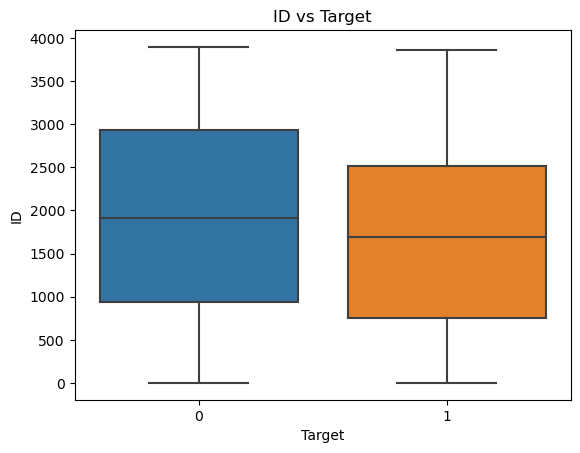

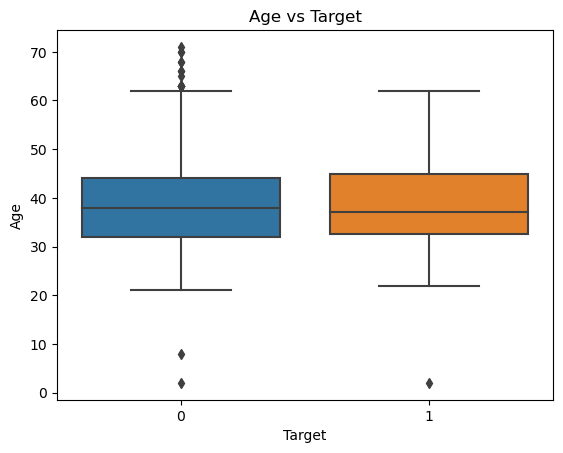

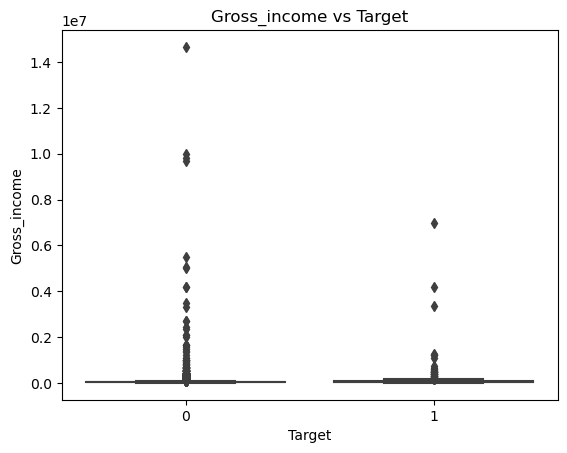

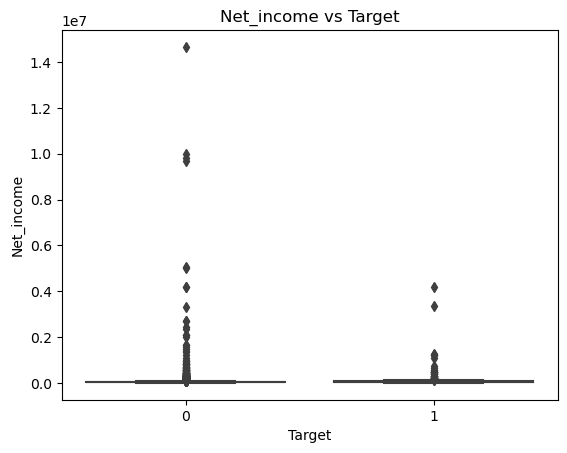

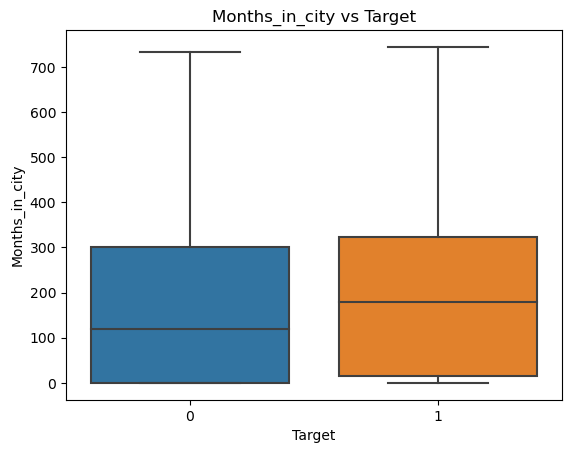

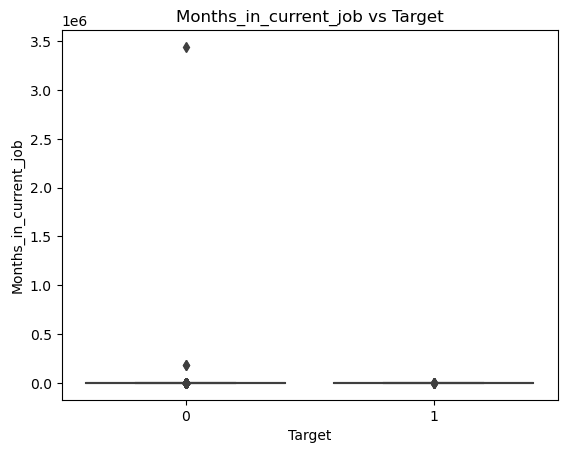

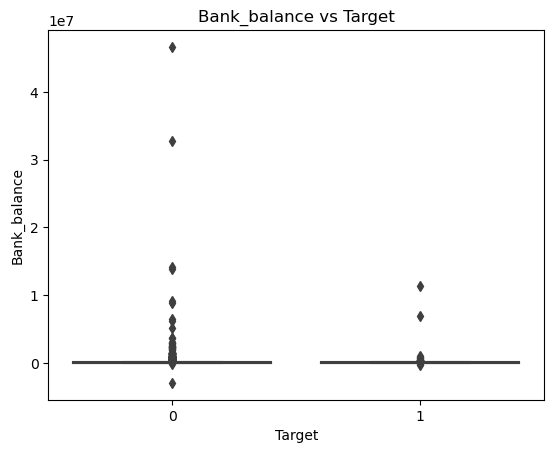

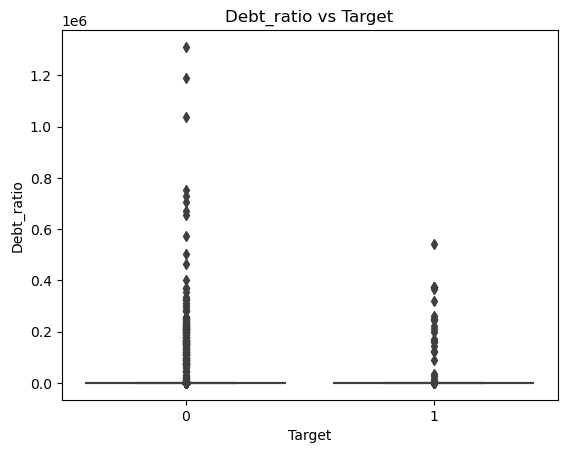

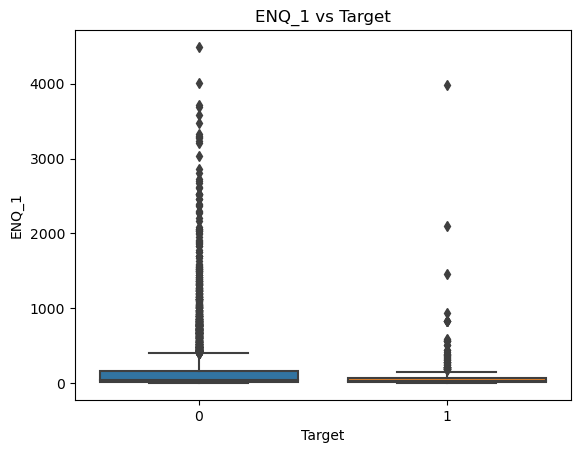

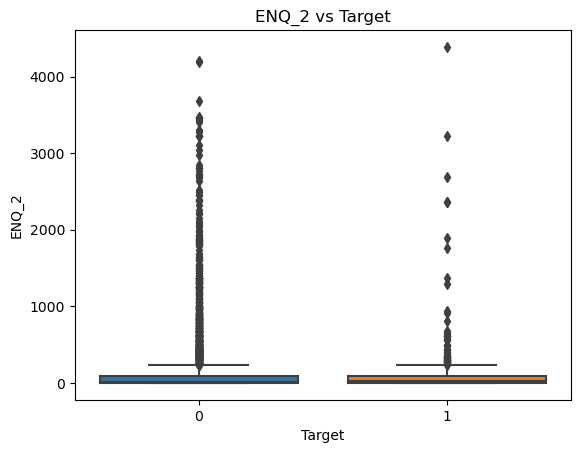

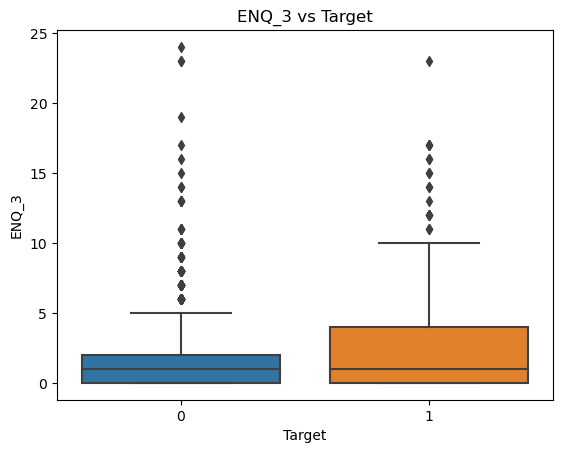

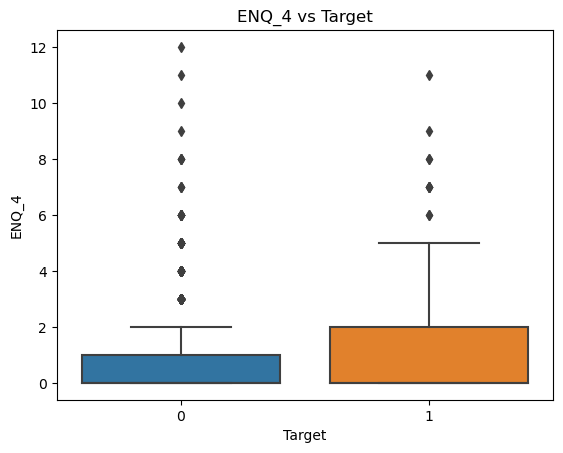

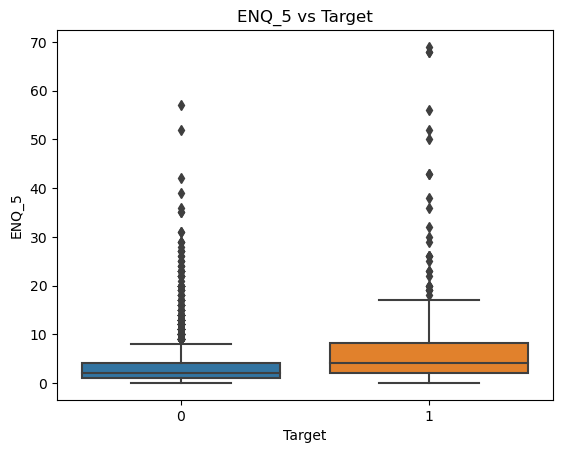

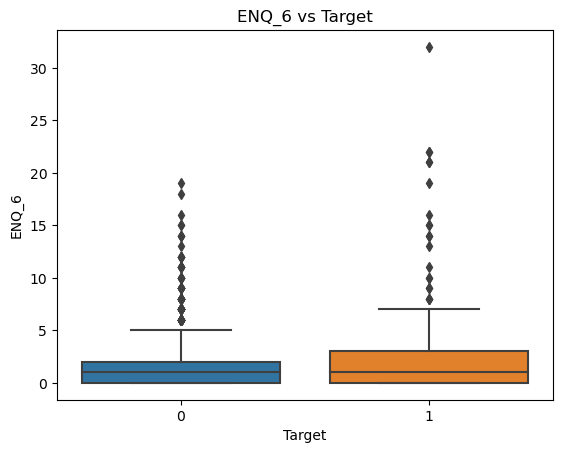

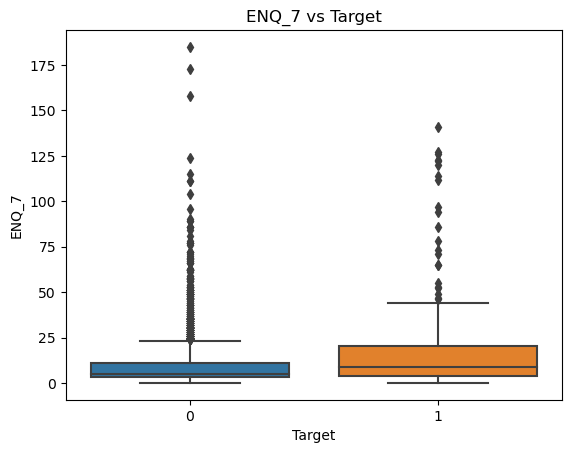

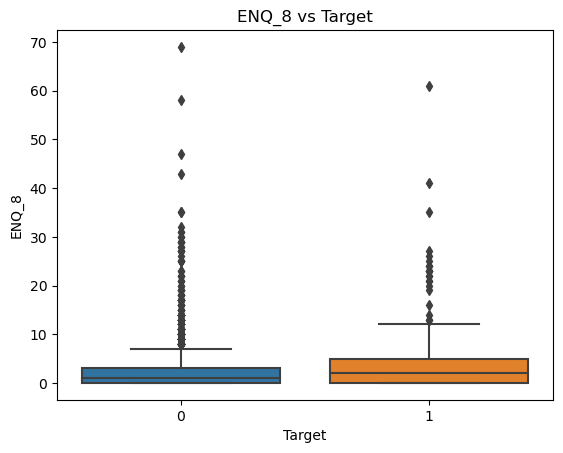

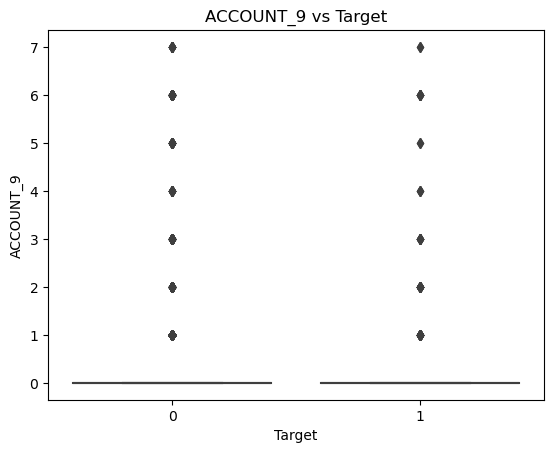

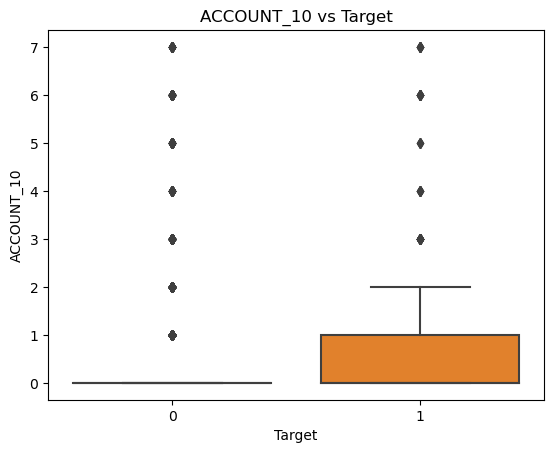

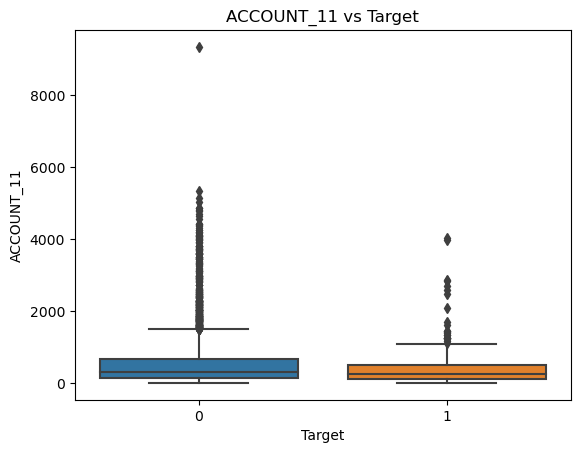

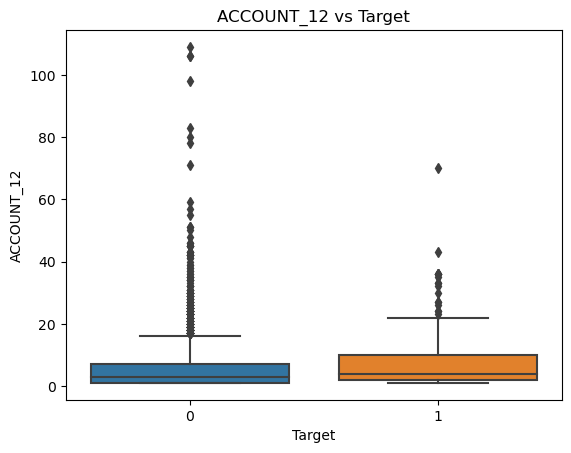

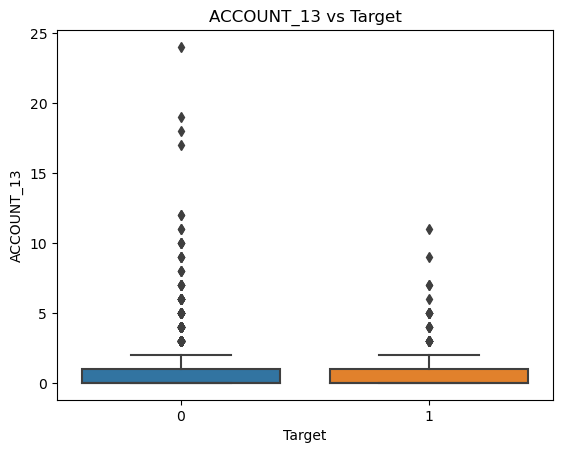

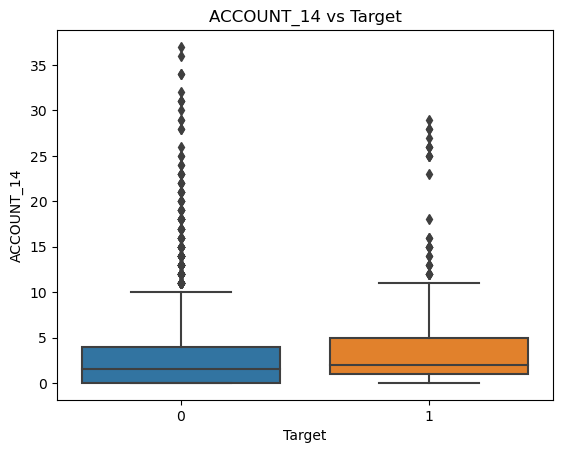

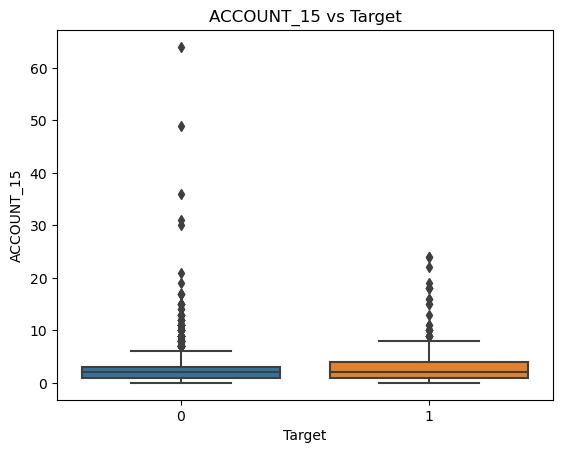

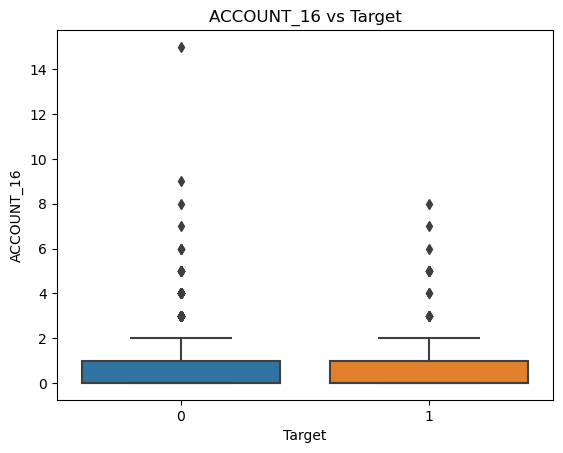

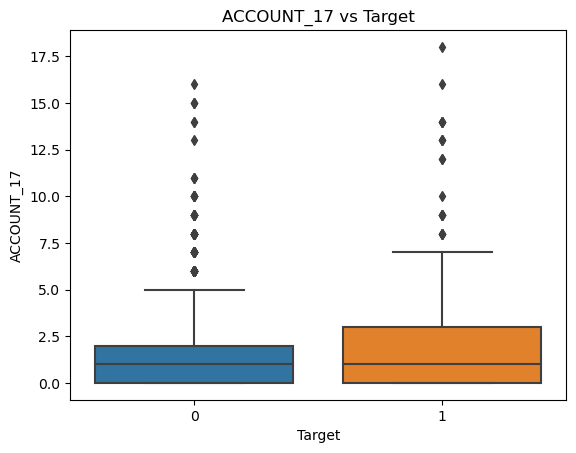

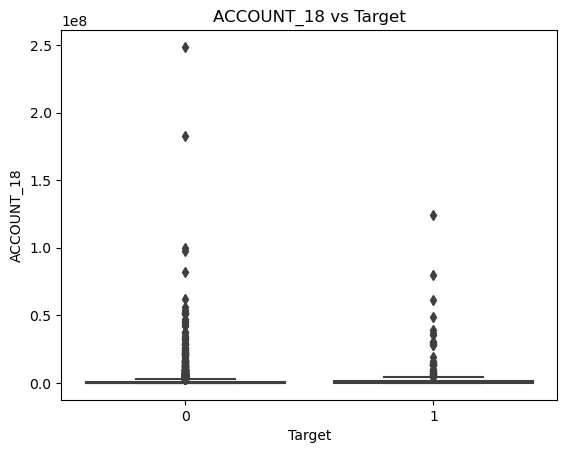

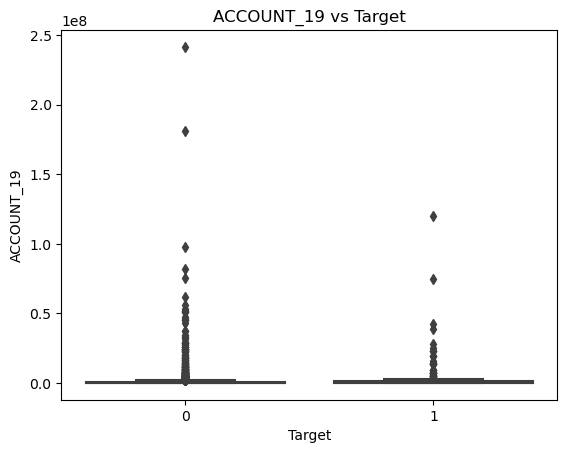

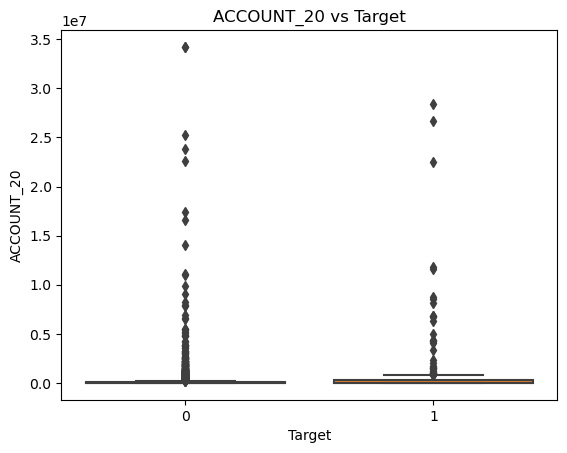

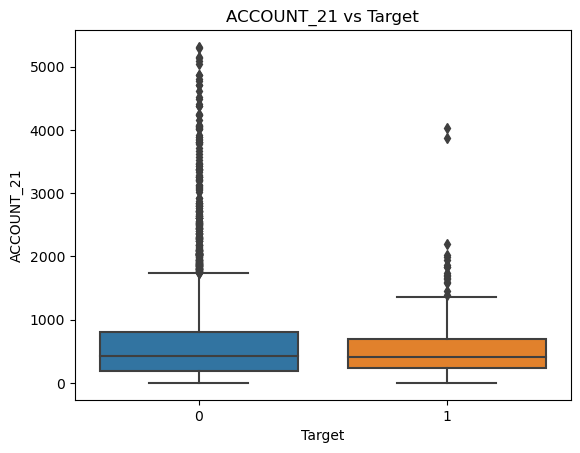

In [13]:
for col in num_cols:
    if col != 'Target':
        sns.boxplot(x=df['Target'], y=df[col])
        plt.title(f"{col} vs Target")
        plt.show()

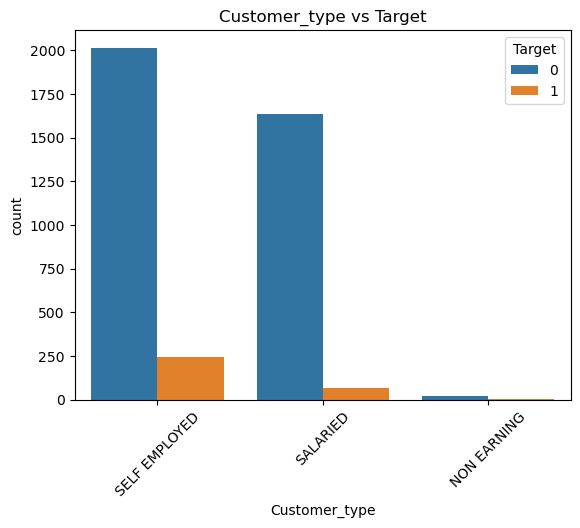

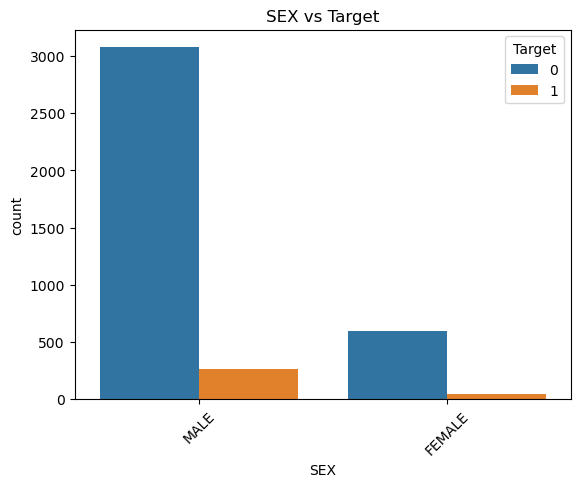

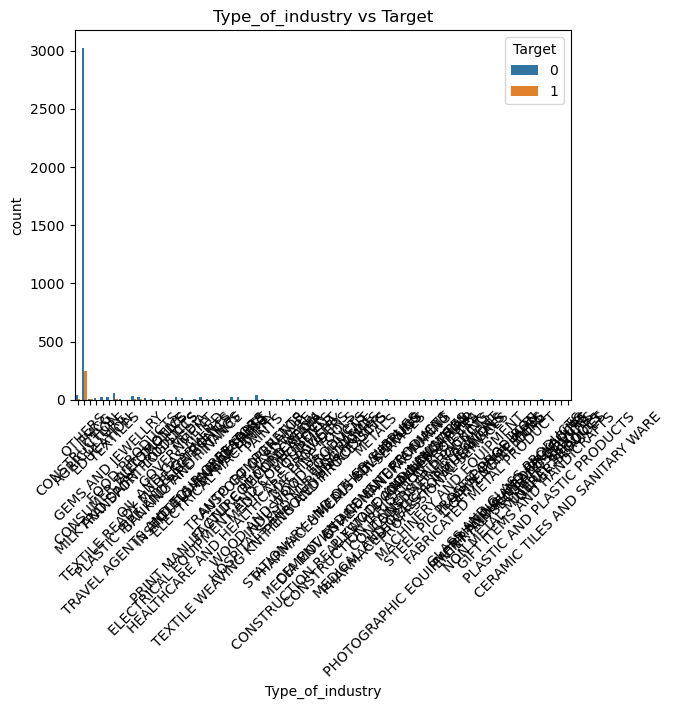

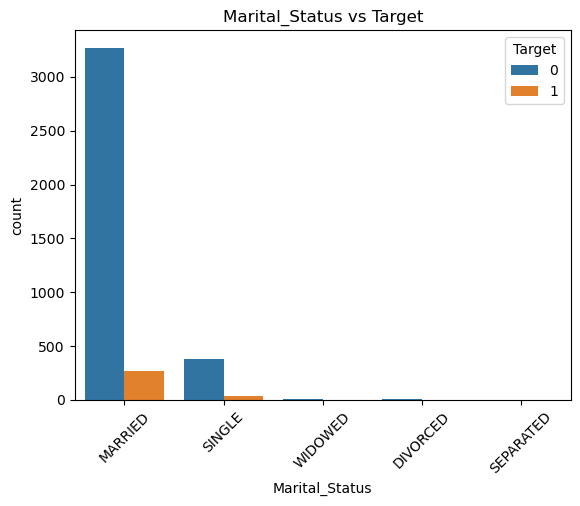

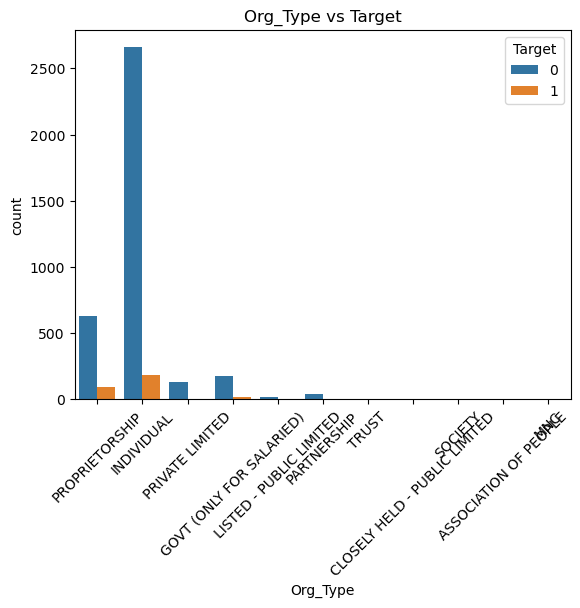

In [14]:
for col in cat_cols:
    if col != 'Target':
        sns.countplot(x=col, hue='Target', data=df)
        plt.xticks(rotation=45)
        plt.title(f"{col} vs Target")
        plt.show()

Multi-variate distribution w.r.t. target variable

In [15]:
num_cols = df.select_dtypes(include=np.number).columns

In [16]:
num_cols_clean = [
    col for col in num_cols
    if df[col].nunique() > 1 and not df[col].isna().all()
]

num_cols_clean

['ID',
 'Age',
 'Gross_income',
 'Net_income',
 'Months_in_city',
 'Months_in_current_job',
 'Bank_balance',
 'Debt_ratio',
 'Target',
 'ENQ_1',
 'ENQ_2',
 'ENQ_3',
 'ENQ_4',
 'ENQ_5',
 'ENQ_6',
 'ENQ_7',
 'ENQ_8',
 'ACCOUNT_9',
 'ACCOUNT_10',
 'ACCOUNT_11',
 'ACCOUNT_12',
 'ACCOUNT_13',
 'ACCOUNT_14',
 'ACCOUNT_15',
 'ACCOUNT_16',
 'ACCOUNT_17',
 'ACCOUNT_18',
 'ACCOUNT_19',
 'ACCOUNT_20',
 'ACCOUNT_21']

In [17]:
pairplot_cols = num_cols_clean[:4]  # you can change 4 → 5

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

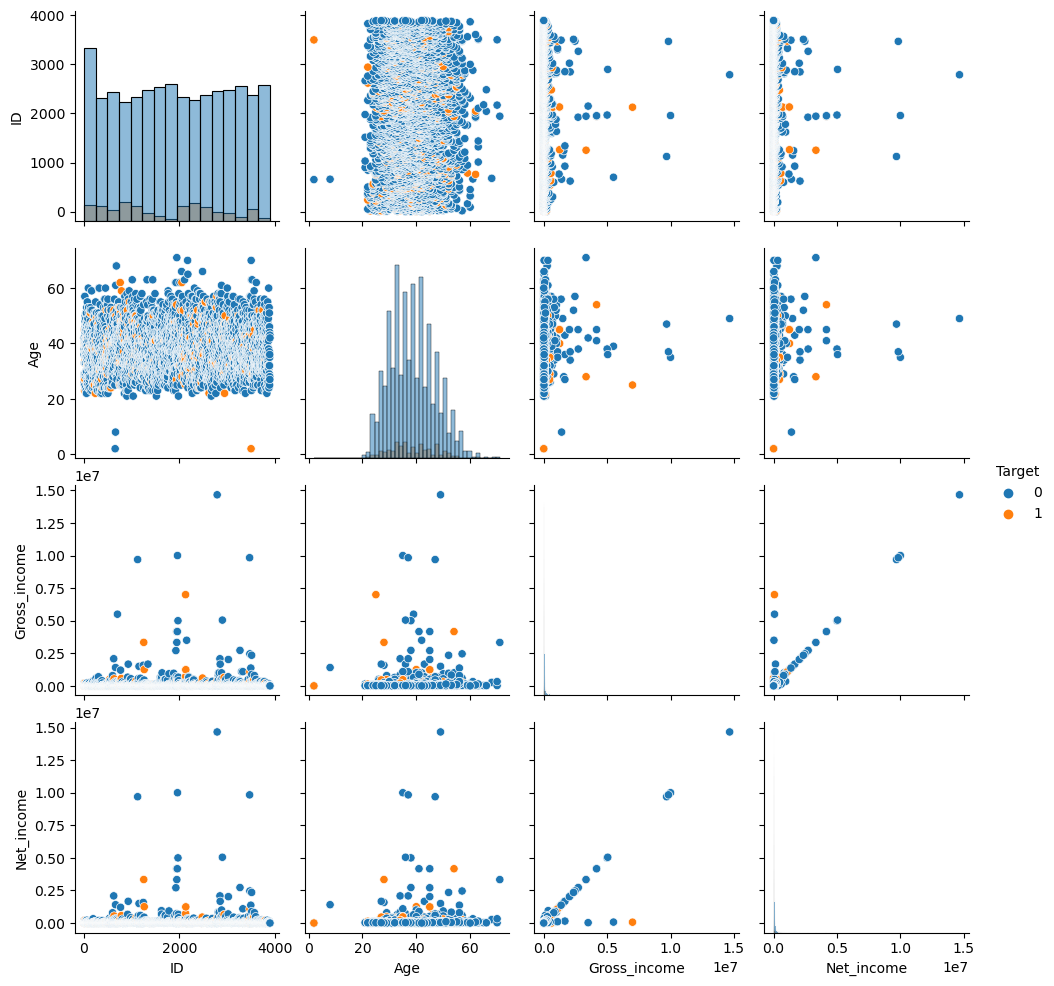

In [18]:
sns.pairplot(df[pairplot_cols + ['Target']], hue='Target', diag_kind='hist')
plt.show()

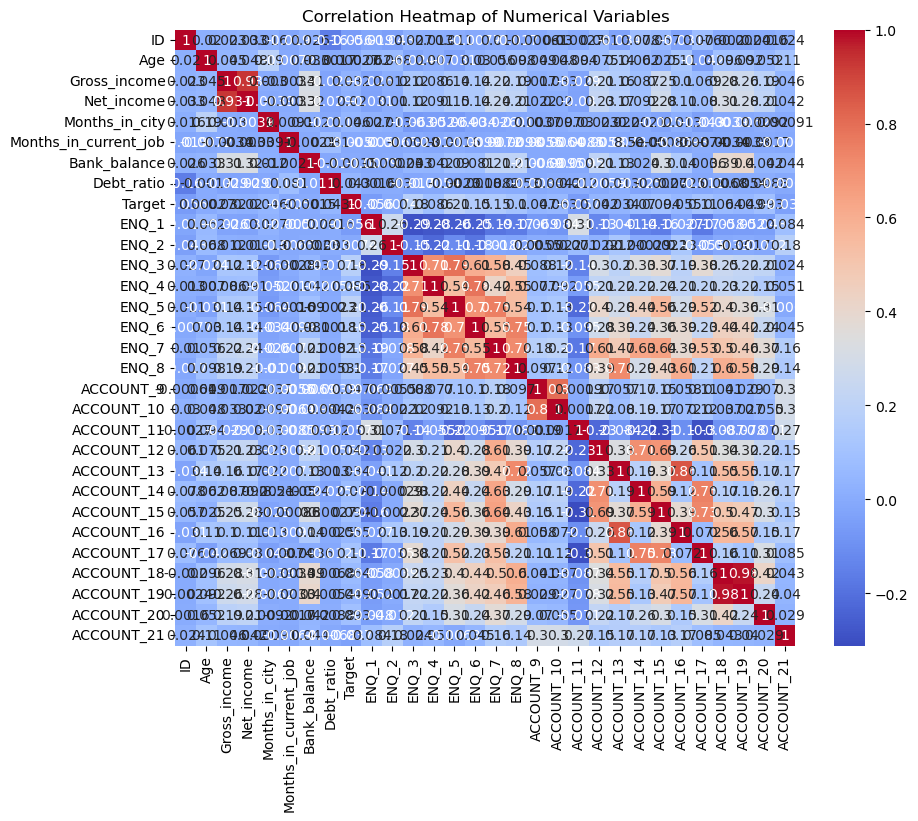

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols_clean].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [20]:
df['Target'].dtype

dtype('int64')

Missing value Treatment :
* Missing at random / not random
* For cases, where missing is due to random factors  --- Missing value treatment

In [21]:
df.isnull().corr()

,ID,Age,Customer_type,Gross_income,Net_income,SEX,Type_of_industry,Marital_Status,Months_in_city,Months_in_current_job,...,ACCOUNT_12,ACCOUNT_13,ACCOUNT_14,ACCOUNT_15,ACCOUNT_16,ACCOUNT_17,ACCOUNT_18,ACCOUNT_19,ACCOUNT_20,ACCOUNT_21
ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,NaN,1.000000,NaN,NaN,NaN,0.499811,-0.000562,0.499811,0.499811,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gross_income,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Net_income,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SEX,NaN,0.499811,NaN,NaN,NaN,1.000000,-0.001125,1.000000,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type_of_industry,NaN,-0.000562,NaN,NaN,NaN,-0.001125,1.000000,-0.001125,-0.001125,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,NaN,0.499811,NaN,NaN,NaN,1.000000,-0.001125,1.000000,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_in_city,NaN,0.499811,NaN,NaN,NaN,1.000000,-0.001125,1.000000,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_in_current_job,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df.isnull().corr()

,ID,Age,Customer_type,Gross_income,Net_income,SEX,Type_of_industry,Marital_Status,Months_in_city,Months_in_current_job,...,ACCOUNT_12,ACCOUNT_13,ACCOUNT_14,ACCOUNT_15,ACCOUNT_16,ACCOUNT_17,ACCOUNT_18,ACCOUNT_19,ACCOUNT_20,ACCOUNT_21
ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,NaN,1.000000,NaN,NaN,NaN,0.499811,-0.000562,0.499811,0.499811,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gross_income,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Net_income,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SEX,NaN,0.499811,NaN,NaN,NaN,1.000000,-0.001125,1.000000,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type_of_industry,NaN,-0.000562,NaN,NaN,NaN,-0.001125,1.000000,-0.001125,-0.001125,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,NaN,0.499811,NaN,NaN,NaN,1.000000,-0.001125,1.000000,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_in_city,NaN,0.499811,NaN,NaN,NaN,1.000000,-0.001125,1.000000,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_in_current_job,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\3421764164.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\3421764164.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [24]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\1925696021.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [25]:
df.isnull().sum()

ID                       0
Age                      0
Customer_type            0
Gross_income             0
Net_income               0
SEX                      0
Type_of_industry         0
Marital_Status           0
Months_in_city           0
Months_in_current_job    0
Org_Type                 0
Bank_balance             0
Debt_ratio               0
Target                   0
ENQ_1                    0
ENQ_2                    0
ENQ_3                    0
ENQ_4                    0
ENQ_5                    0
ENQ_6                    0
ENQ_7                    0
ENQ_8                    0
ACCOUNT_9                0
ACCOUNT_10               0
ACCOUNT_11               0
ACCOUNT_12               0
ACCOUNT_13               0
ACCOUNT_14               0
ACCOUNT_15               0
ACCOUNT_16               0
ACCOUNT_17               0
ACCOUNT_18               0
ACCOUNT_19               0
ACCOUNT_20               0
ACCOUNT_21               0
dtype: int64

### 2. Segmentation

Identifying possible segments (if any)

If you opt for segmentation, 
Please note, all of the below steps needs to be performed for each segment independently 

In [26]:
# Example segmentation by age bands (edit if needed)
df['age_segment'] = pd.cut(
    df['Age'],
    bins=[18, 30, 45, 60, 100],
    labels=['Young', 'Mid', 'Senior', 'Old']
)

In [27]:
df['age_segment'].value_counts()

age_segment
Mid       2411
Senior     800
Young      744
Old         22
Name: count, dtype: int64

### 3. Variable creation

* conversion of enquiry to account ( Total accounts / Total enquiries )
* ratio of unsecured exporsure ( unsecure outstanding / total outstanding )
* ratio of home loan to all loans
* ratio of last 12 months enquiery to all enquiries 
* age to income ratio
* live vs total loans
* total loans by age
* etc 
 
 create in total, at least 18 additional variables

In [28]:
df.columns

Index(['ID', 'Age', 'Customer_type', 'Gross_income', 'Net_income', 'SEX',
       'Type_of_industry', 'Marital_Status', 'Months_in_city',
       'Months_in_current_job', 'Org_Type', 'Bank_balance', 'Debt_ratio',
       'Target', 'ENQ_1', 'ENQ_2', 'ENQ_3', 'ENQ_4', 'ENQ_5', 'ENQ_6', 'ENQ_7',
       'ENQ_8', 'ACCOUNT_9', 'ACCOUNT_10', 'ACCOUNT_11', 'ACCOUNT_12',
       'ACCOUNT_13', 'ACCOUNT_14', 'ACCOUNT_15', 'ACCOUNT_16', 'ACCOUNT_17',
       'ACCOUNT_18', 'ACCOUNT_19', 'ACCOUNT_20', 'ACCOUNT_21', 'age_segment'],
      dtype='object')

In [29]:
# Total enquiries
enq_cols = ['ENQ_1','ENQ_2','ENQ_3','ENQ_4','ENQ_5','ENQ_6','ENQ_7','ENQ_8']
df['total_enquiries'] = df[enq_cols].sum(axis=1)

In [30]:
# Total accounts
acct_cols = [
    'ACCOUNT_9','ACCOUNT_10','ACCOUNT_11','ACCOUNT_12','ACCOUNT_13',
    'ACCOUNT_14','ACCOUNT_15','ACCOUNT_16','ACCOUNT_17','ACCOUNT_18',
    'ACCOUNT_19','ACCOUNT_20','ACCOUNT_21'
]
df['total_accounts'] = df[acct_cols].sum(axis=1)

In [31]:
df['enquiry_to_account_ratio'] = df['total_accounts'] / (df['total_enquiries'] + 1)

In [32]:
df['recent_enquiry_ratio'] = (df['ENQ_7'] + df['ENQ_8']) / (df['total_enquiries'] + 1)

In [33]:
df['age_to_net_income_ratio'] = df['Age'] / (df['Net_income'] + 1)

In [34]:
df['gross_to_net_income_ratio'] = df['Gross_income'] / (df['Net_income'] + 1)

In [35]:
df['debt_to_income_ratio'] = df['Debt_ratio'] / (df['Net_income'] + 1)

In [36]:
df['accounts_per_age'] = df['total_accounts'] / (df['Age'] + 1)

In [37]:
df['enquiries_per_age'] = df['total_enquiries'] / (df['Age'] + 1)

In [38]:
df['accounts_per_city_month'] = df['total_accounts'] / (df['Months_in_city'] + 1)

In [39]:
df['enquiries_per_job_month'] = df['total_enquiries'] / (df['Months_in_current_job'] + 1)

In [40]:
df['account_stability_ratio'] = df['Months_in_current_job'] / (df['total_accounts'] + 1)

In [41]:
df['bank_balance_to_income'] = df['Bank_balance'] / (df['Net_income'] + 1)

In [42]:
df['bank_balance_to_debt'] = df['Bank_balance'] / (df['Debt_ratio'] + 1)

In [43]:
df['income_per_account'] = df['Net_income'] / (df['total_accounts'] + 1)

In [44]:
df['gross_income_per_enquiry'] = df['Gross_income'] / (df['total_enquiries'] + 1)

In [45]:
df['enquiry_intensity'] = df['total_enquiries'] / (df['Months_in_city'] + 1)

In [46]:
df['account_intensity'] = df['total_accounts'] / (df['Months_in_city'] + 1)

In [47]:
df['financial_pressure_index'] = (
    df['Debt_ratio'] * df['total_enquiries']
) / (df['Net_income'] + 1)

In [48]:
df['credit_maturity_score'] = (
    df['Months_in_current_job'] + df['Months_in_city']
) / (df['Age'] + 1)

In [49]:
df[
    [
        'total_enquiries',
        'total_accounts',
        'enquiry_to_account_ratio',
        'age_to_net_income_ratio',
        'bank_balance_to_income',
        'financial_pressure_index'
    ]
].head()

,total_enquiries,total_accounts,enquiry_to_account_ratio,age_to_net_income_ratio,bank_balance_to_income,financial_pressure_index
0,284,3676850,12901.228070,0.000458,2.918499,0.001952
1,284,3676850,12901.228070,0.000458,2.918499,0.001952
2,14,21016,1401.066667,0.001267,0.435285,0.000182
3,14,21016,1401.066667,0.001267,0.435285,0.000182
4,105,6893184,65030.037736,0.000191,0.135144,0.000246


### 4. Variable Reduction

* Variable importance using Random Forest
* Variable importance using IV
* Correlation
* Variable Cluster ( Optional )

In [51]:
X = df.drop(columns=['Target', 'ID'], errors='ignore')
y = df['Target']

In [52]:
X_num = X.select_dtypes(include=np.number)
X_num.shape

(3980, 48)

In [53]:
corr_matrix = X_num.corr().abs()

In [54]:
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [55]:
high_corr_cols = [
    col for col in upper_tri.columns if any(upper_tri[col] > 0.75)
]

high_corr_cols

['Net_income',
 'ENQ_5',
 'ENQ_6',
 'ENQ_7',
 'ACCOUNT_10',
 'ACCOUNT_16',
 'ACCOUNT_19',
 'total_enquiries',
 'total_accounts',
 'debt_to_income_ratio',
 'accounts_per_age',
 'enquiries_per_age',
 'accounts_per_city_month',
 'account_stability_ratio',
 'bank_balance_to_debt',
 'account_intensity',
 'credit_maturity_score']

In [56]:
X_corr_reduced = X_num.drop(columns=high_corr_cols)
X_corr_reduced.shape

(3980, 31)

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_corr_reduced, y)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [59]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_corr_reduced.columns
).sort_values(ascending=False)

rf_importance.head(20)

bank_balance_to_income       0.051403
ENQ_1                        0.046542
age_to_net_income_ratio      0.045805
ACCOUNT_11                   0.044809
Bank_balance                 0.043889
enquiry_intensity            0.043734
ACCOUNT_21                   0.041914
enquiries_per_job_month      0.041850
gross_to_net_income_ratio    0.041156
Debt_ratio                   0.041109
recent_enquiry_ratio         0.040264
Gross_income                 0.039448
gross_income_per_enquiry     0.038271
ENQ_3                        0.037922
enquiry_to_account_ratio     0.035962
income_per_account           0.035603
ACCOUNT_18                   0.033405
financial_pressure_index     0.032707
Months_in_current_job        0.031384
Age                          0.031096
dtype: float64

In [60]:
# Keep top 20 variables
top_rf_features = rf_importance.head(20).index.tolist()
X_rf_reduced = X_corr_reduced[top_rf_features]
X_rf_reduced.shape

(3980, 20)

In [61]:
def calculate_iv(data, feature, target):
    eps = 0.0001
    df_iv = pd.crosstab(data[feature], data[target])
    df_iv.columns = ['Good', 'Bad']
    df_iv['Good'] = df_iv['Good'] / df_iv['Good'].sum()
    df_iv['Bad'] = df_iv['Bad'] / df_iv['Bad'].sum()
    df_iv['WoE'] = np.log((df_iv['Good'] + eps) / (df_iv['Bad'] + eps))
    df_iv['IV'] = (df_iv['Good'] - df_iv['Bad']) * df_iv['WoE']
    return df_iv['IV'].sum()

In [62]:
iv_values = {}

for col in X_rf_reduced.columns:
    try:
        iv_values[col] = calculate_iv(df, col, 'Target')
    except:
        iv_values[col] = np.nan

In [63]:
iv_df = (
    pd.DataFrame.from_dict(iv_values, orient='index', columns=['IV'])
    .sort_values(by='IV', ascending=False)
)

iv_df

,IV
enquiry_to_account_ratio,4.979729
income_per_account,4.853050
bank_balance_to_income,4.781467
gross_income_per_enquiry,4.706959
financial_pressure_index,4.579972
age_to_net_income_ratio,4.573266
enquiries_per_job_month,4.347990
enquiry_intensity,4.286187
ACCOUNT_18,4.279427
Bank_balance,4.164031


In [64]:
# Industry rule: IV > 0.02 is acceptable
selected_iv_features = iv_df[iv_df['IV'] > 0.02].index.tolist()
selected_iv_features

['enquiry_to_account_ratio',
 'income_per_account',
 'bank_balance_to_income',
 'gross_income_per_enquiry',
 'financial_pressure_index',
 'age_to_net_income_ratio',
 'enquiries_per_job_month',
 'enquiry_intensity',
 'ACCOUNT_18',
 'Bank_balance',
 'recent_enquiry_ratio',
 'gross_to_net_income_ratio',
 'Gross_income',
 'ACCOUNT_21',
 'ACCOUNT_11',
 'ENQ_1',
 'Debt_ratio',
 'Months_in_current_job',
 'ENQ_3',
 'Age']

In [65]:
X_final = X_rf_reduced[selected_iv_features]
X_final.shape

(3980, 20)

In [66]:
final_features = X_final.columns.tolist()
final_features

['enquiry_to_account_ratio',
 'income_per_account',
 'bank_balance_to_income',
 'gross_income_per_enquiry',
 'financial_pressure_index',
 'age_to_net_income_ratio',
 'enquiries_per_job_month',
 'enquiry_intensity',
 'ACCOUNT_18',
 'Bank_balance',
 'recent_enquiry_ratio',
 'gross_to_net_income_ratio',
 'Gross_income',
 'ACCOUNT_21',
 'ACCOUNT_11',
 'ENQ_1',
 'Debt_ratio',
 'Months_in_current_job',
 'ENQ_3',
 'Age']

In [67]:
X_final.isnull().sum().sum()

0

In [68]:
X_final.head()

,enquiry_to_account_ratio,income_per_account,bank_balance_to_income,gross_income_per_enquiry,financial_pressure_index,age_to_net_income_ratio,enquiries_per_job_month,enquiry_intensity,ACCOUNT_18,Bank_balance,recent_enquiry_ratio,gross_to_net_income_ratio,Gross_income,ACCOUNT_21,ACCOUNT_11,ENQ_1,Debt_ratio,Months_in_current_job,ENQ_3,Age
0,12901.228070,0.024931,2.918499,321.637439,0.001952,0.000458,2.927835,284.0,1837374,267532.0,0.112281,0.999989,91666.67,1657,419,17,0.63,96,1,42.0
1,12901.228070,0.024931,2.918499,321.637439,0.001952,0.000458,2.927835,284.0,1837374,267532.0,0.112281,0.999989,91666.67,1657,419,17,0.63,96,1,42.0
2,1401.066667,1.427416,0.435285,10000.000000,0.000182,0.001267,0.115702,14.0,10380,13059.0,0.400000,4.999833,150000.00,124,121,5,0.39,120,1,38.0
3,1401.066667,1.427416,0.435285,10000.000000,0.000182,0.001267,0.115702,14.0,10380,13059.0,0.400000,4.999833,150000.00,124,121,5,0.39,120,1,38.0
4,65030.037736,0.027300,0.135144,1775.314434,0.000246,0.000191,105.000000,105.0,3445241,25432.0,0.575472,0.999995,188183.33,2534,87,5,0.44,0,7,36.0


### 5. Data Split ( Dev : OOS , 70 : 30)

In [69]:
df['Target'] = df['Target'].astype(int)

In [70]:
try:
    final_features
except NameError:
    final_features = df.select_dtypes(include=np.number).drop(columns=['Target'], errors='ignore').columns.tolist()

In [71]:
X = df[final_features]
y = df['Target']

In [72]:
from sklearn.model_selection import train_test_split

X_dev, X_oos, y_dev, y_oos = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [73]:
dev = X_dev.copy()
dev['Target'] = y_dev.values

oos = X_oos.copy()
oos['Target'] = y_oos.values

In [74]:
dev.shape, oos.shape

((2786, 21), (1194, 21))

In [75]:
dev['Target'].value_counts(normalize=True)

Target
0    0.922469
1    0.077531
Name: proportion, dtype: float64

In [76]:
oos['Target'].value_counts(normalize=True)

Target
0    0.922948
1    0.077052
Name: proportion, dtype: float64

In [77]:
dev.to_csv("dev_dataset.csv", index=False)
oos.to_csv("oos_dataset.csv", index=False)

### 6. Coarse Classing / Binning

To be done, only on the development data
* Decision Trees (or) IV/WOE



#### If you are opting for IV/WOE
* Run a loop similar to IV
* Calculate Bad-Rate ( i.e. bad/total for each decile )
* study the bad rate 
* Check whether a logical trend can be identified 
* If no - Delete the variable
* If yes - Identify appropriate cut-off

#### If you are opting for Decision Trees
* Create Decision Stumps for each variable 
* Check whether a logical trend can be identified 
* If no - Delete the variable
* If yes - perhaps you can consider sharping the buckets, may or may not be required


In [78]:
num_vars = dev.select_dtypes(include=np.number).columns.drop('Target')
num_vars

Index(['enquiry_to_account_ratio', 'income_per_account',
       'bank_balance_to_income', 'gross_income_per_enquiry',
       'financial_pressure_index', 'age_to_net_income_ratio',
       'enquiries_per_job_month', 'enquiry_intensity', 'ACCOUNT_18',
       'Bank_balance', 'recent_enquiry_ratio', 'gross_to_net_income_ratio',
       'Gross_income', 'ACCOUNT_21', 'ACCOUNT_11', 'ENQ_1', 'Debt_ratio',
       'Months_in_current_job', 'ENQ_3', 'Age'],
      dtype='object')

In [79]:
binned_vars = {}

for col in num_vars:
    try:
        dev[col + '_bin'] = pd.qcut(dev[col], q=10, duplicates='drop')
        binned_vars[col] = col + '_bin'
    except:
        pass

In [80]:
list(binned_vars.values())

['enquiry_to_account_ratio_bin',
 'income_per_account_bin',
 'bank_balance_to_income_bin',
 'gross_income_per_enquiry_bin',
 'financial_pressure_index_bin',
 'age_to_net_income_ratio_bin',
 'enquiries_per_job_month_bin',
 'enquiry_intensity_bin',
 'ACCOUNT_18_bin',
 'Bank_balance_bin',
 'recent_enquiry_ratio_bin',
 'gross_to_net_income_ratio_bin',
 'Gross_income_bin',
 'ACCOUNT_21_bin',
 'ACCOUNT_11_bin',
 'ENQ_1_bin',
 'Debt_ratio_bin',
 'Months_in_current_job_bin',
 'ENQ_3_bin',
 'Age_bin']

In [81]:
def bad_rate_table(data, bin_col, target='Target'):
    return (
        data.groupby(bin_col)[target]
        .agg(['count', 'sum'])
        .rename(columns={'sum': 'bad'})
        .assign(bad_rate=lambda x: x['bad'] / x['count'])
    )

In [82]:
bad_rate_tables = {}

for col, bin_col in binned_vars.items():
    bad_rate_tables[col] = bad_rate_table(dev, bin_col)

C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\3135384678.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(bin_col)[target]
C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\3135384678.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(bin_col)[target]
C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\3135384678.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(bin

In [83]:
# Example: Age
bad_rate_tables['Age']

,count,bad,bad_rate
Age_bin,,,
"(1.999, 28.0]",325,25,0.076923
"(28.0, 31.0]",313,19,0.060703
"(31.0, 33.0]",253,21,0.083004
"(33.0, 35.0]",231,29,0.125541
"(35.0, 38.0]",369,23,0.062331
"(38.0, 40.0]",206,12,0.058252
"(40.0, 43.0]",326,26,0.079755
"(43.0, 46.0]",260,14,0.053846
"(46.0, 50.0]",263,29,0.110266


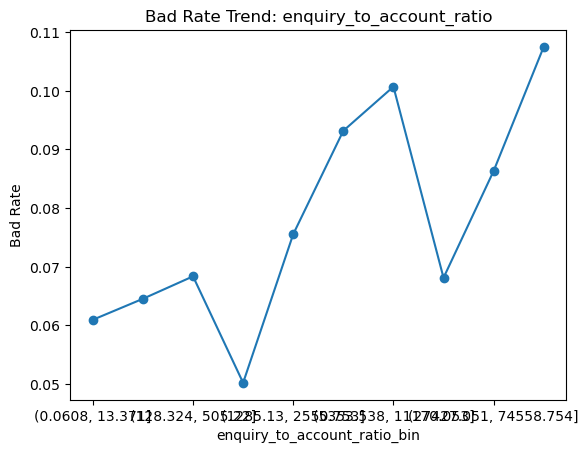

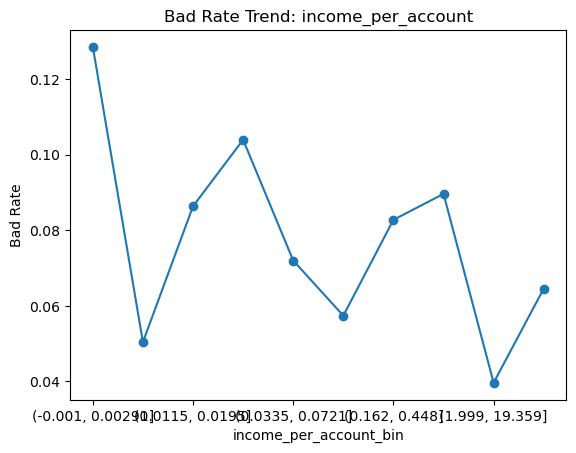

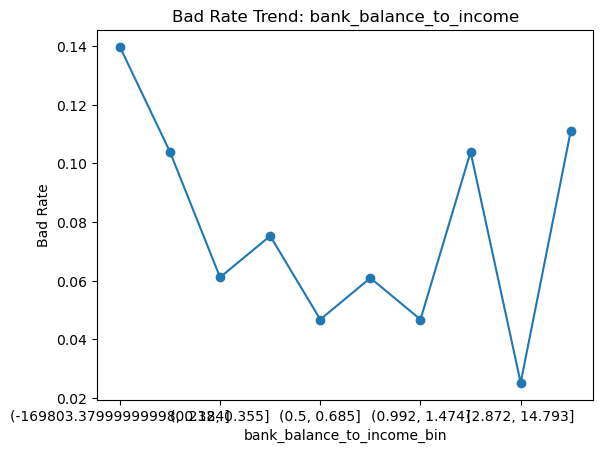

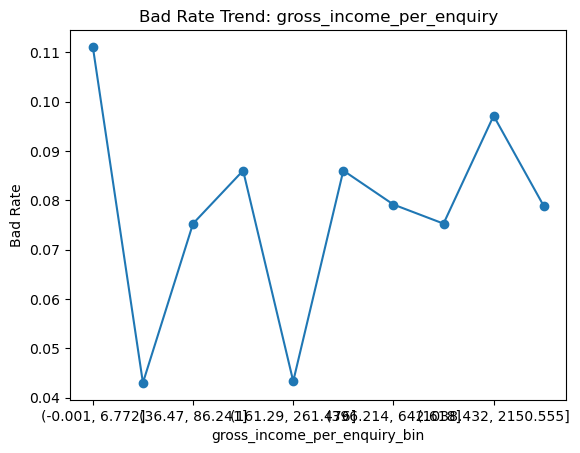

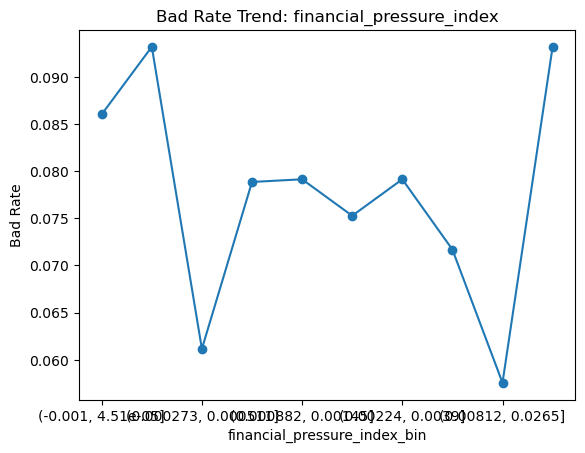

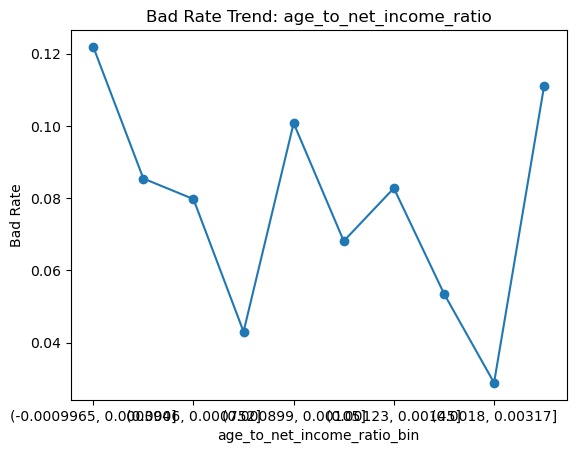

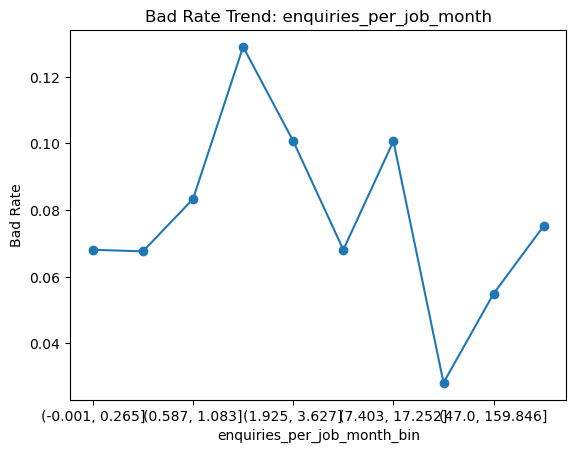

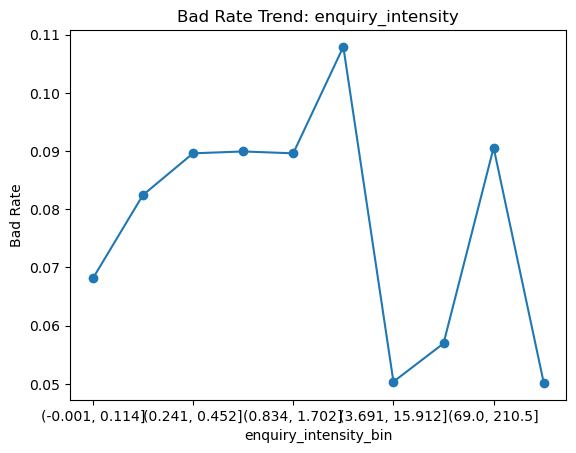

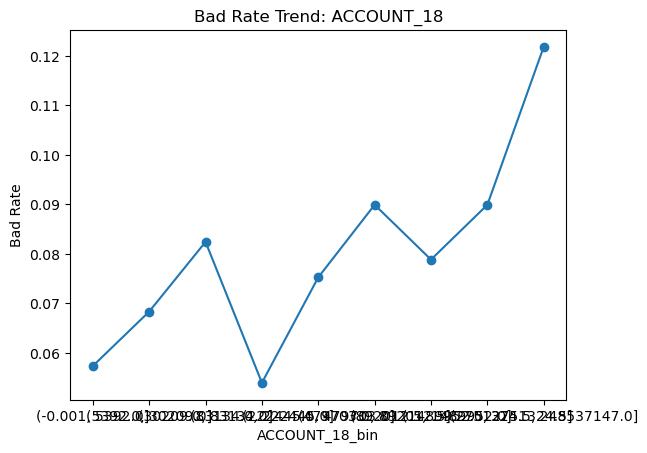

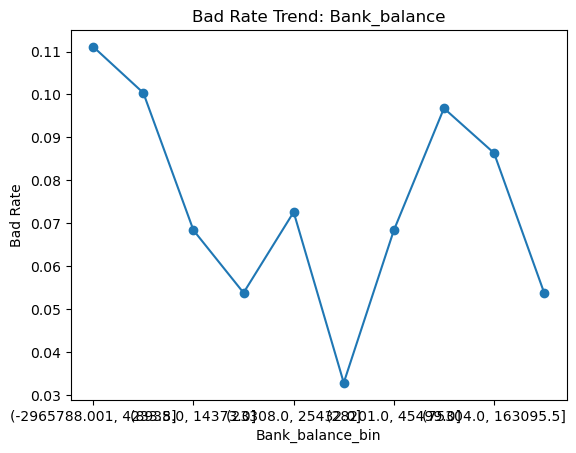

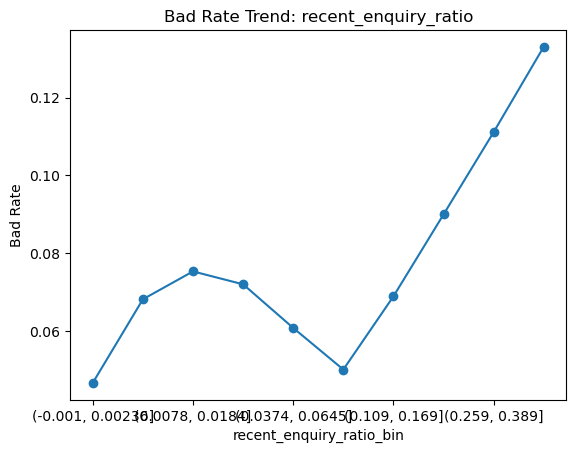

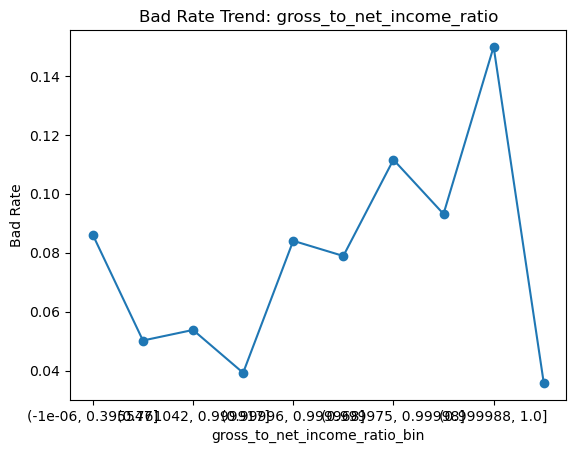

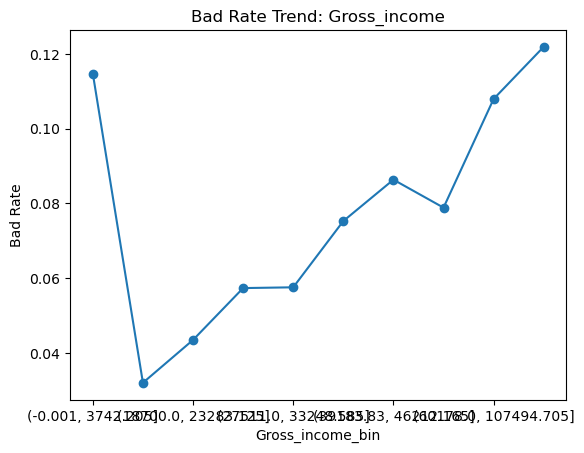

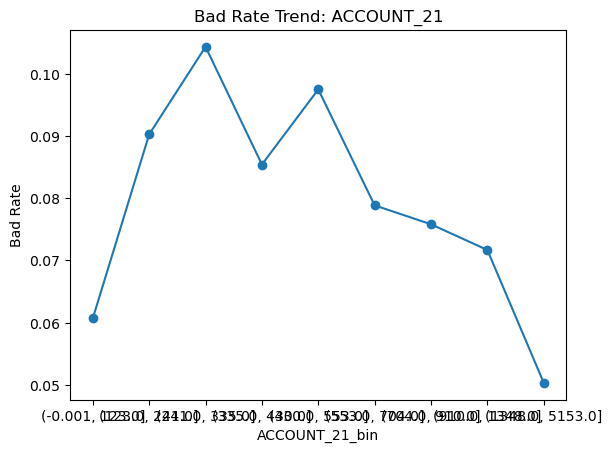

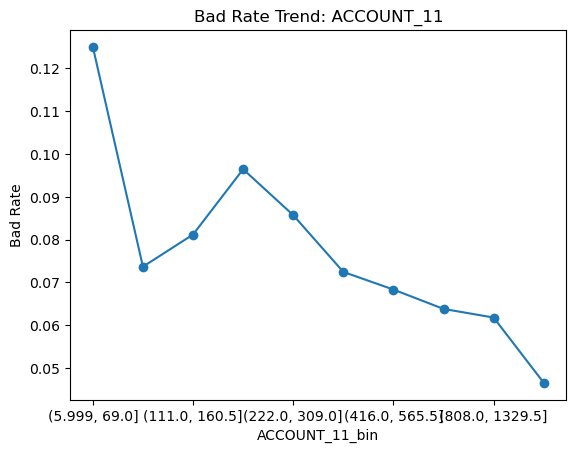

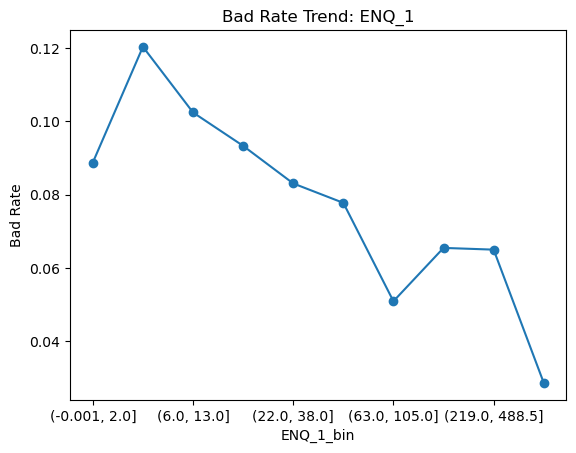

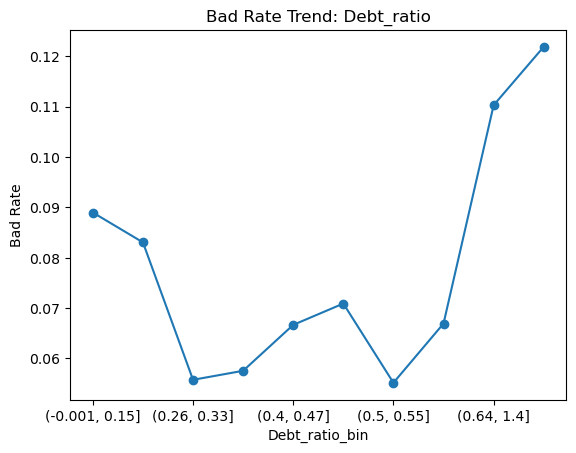

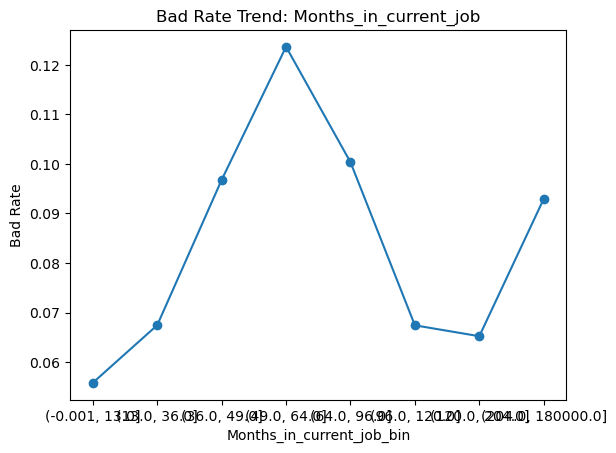

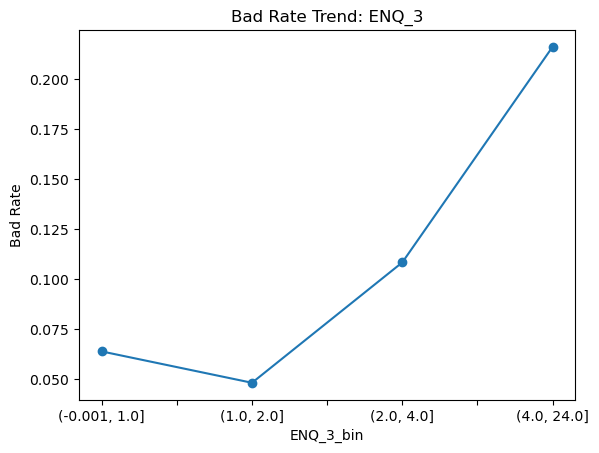

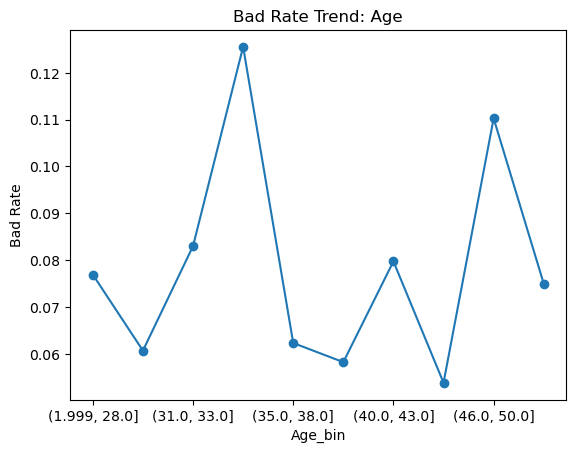

In [84]:
for col, bin_col in binned_vars.items():
    bad_rate_tables[col]['bad_rate'].plot(
        kind='line', marker='o', title=f'Bad Rate Trend: {col}'
    )
    plt.ylabel('Bad Rate')
    plt.show()

In [85]:
# Example manual binning for Age
dev['Age_coarse'] = pd.cut(
    dev['Age'],
    bins=[18, 30, 45, 60, 100]
)

In [86]:
bad_rate_table(dev, 'Age_coarse')

C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\3135384678.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(bin_col)[target]


,count,bad,bad_rate
Age_coarse,,,
"(18, 30]",517,34,0.065764
"(30, 45]",1690,129,0.076331
"(45, 60]",565,50,0.088496
"(60, 100]",11,2,0.181818


In [87]:
coarse_vars = [col for col in dev.columns if col.endswith('_bin') or col.endswith('_coarse')]
coarse_vars

['enquiry_to_account_ratio_bin',
 'income_per_account_bin',
 'bank_balance_to_income_bin',
 'gross_income_per_enquiry_bin',
 'financial_pressure_index_bin',
 'age_to_net_income_ratio_bin',
 'enquiries_per_job_month_bin',
 'enquiry_intensity_bin',
 'ACCOUNT_18_bin',
 'Bank_balance_bin',
 'recent_enquiry_ratio_bin',
 'gross_to_net_income_ratio_bin',
 'Gross_income_bin',
 'ACCOUNT_21_bin',
 'ACCOUNT_11_bin',
 'ENQ_1_bin',
 'Debt_ratio_bin',
 'Months_in_current_job_bin',
 'ENQ_3_bin',
 'Age_bin',
 'Age_coarse']

In [23]:
# for reference purpose ( please note - No data processing or segmentation was performed , just a referral )

#df['ENQ_5_bkt'] = pd.qcut( df['ENQ_5'] , 10, duplicates = 'drop')
#t = df.pivot_table( index = 'ENQ_5_bkt' , values = 'ID', columns = 'Target' , aggfunc = 'count', margins = True)
#t['bad_rate'] = t[1]/ t['All']*100
#t['IV'] = (t['good_dist'] - t['bad_dist']) * np.log(t['good_dist']/t['bad_dist']) 
#t

### 7. Check the trend on validation sample

After step 6, you will have only categorical variables in your model.
All the numeric variables ( which were following a logical trend ) you must have binned them

Check,
Whether those same bins, continue to show similar trend even on validation sample

In [88]:
# Apply same quantile bins from DEV to OOS
for col in num_vars:
    if col + '_bin' in dev.columns:
        try:
            oos[col + '_bin'] = pd.cut(
                oos[col],
                bins=dev[col + '_bin'].cat.categories
            )
        except:
            pass


In [89]:
oos_bad_rate_tables = {}

for col in num_vars:
    bin_col = col + '_bin'
    if bin_col in oos.columns:
        oos_bad_rate_tables[col] = bad_rate_table(oos, bin_col)


C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\3135384678.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(bin_col)[target]
C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\3135384678.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(bin_col)[target]
C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\3135384678.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(bin

In [90]:
print("DEV Bad Rate (Age)")
display(bad_rate_tables['Age'])

print("OOS Bad Rate (Age)")
display(oos_bad_rate_tables['Age'])


DEV Bad Rate (Age)


,count,bad,bad_rate
Age_bin,,,
"(1.999, 28.0]",325,25,0.076923
"(28.0, 31.0]",313,19,0.060703
"(31.0, 33.0]",253,21,0.083004
"(33.0, 35.0]",231,29,0.125541
"(35.0, 38.0]",369,23,0.062331
"(38.0, 40.0]",206,12,0.058252
"(40.0, 43.0]",326,26,0.079755
"(43.0, 46.0]",260,14,0.053846
"(46.0, 50.0]",263,29,0.110266


OOS Bad Rate (Age)


,count,bad,bad_rate
Age_bin,,,
"(1.999, 28.0]",150,13,0.086667
"(28.0, 31.0]",129,8,0.062016
"(31.0, 33.0]",114,8,0.070175
"(33.0, 35.0]",101,10,0.099010
"(35.0, 38.0]",144,8,0.055556
"(38.0, 40.0]",92,8,0.086957
"(40.0, 43.0]",154,13,0.084416
"(43.0, 46.0]",92,8,0.086957
"(46.0, 50.0]",122,9,0.073770


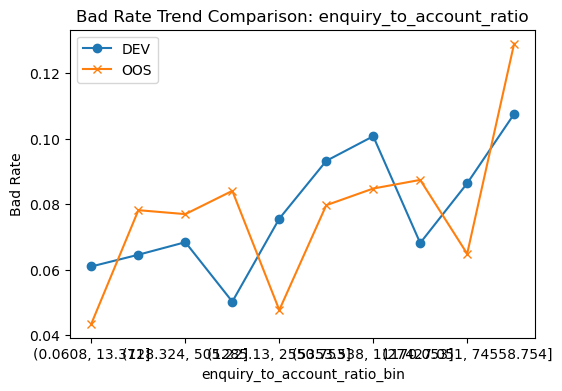

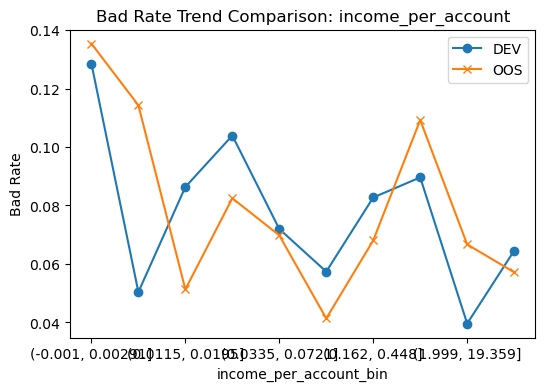

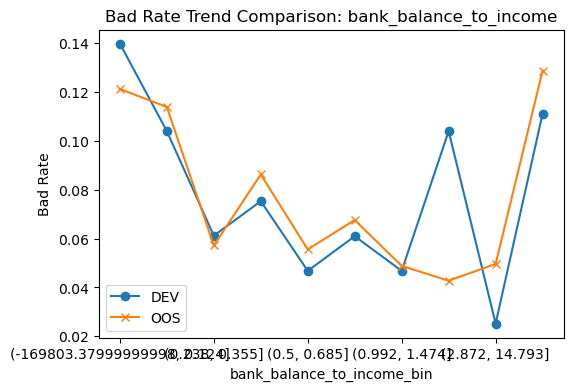

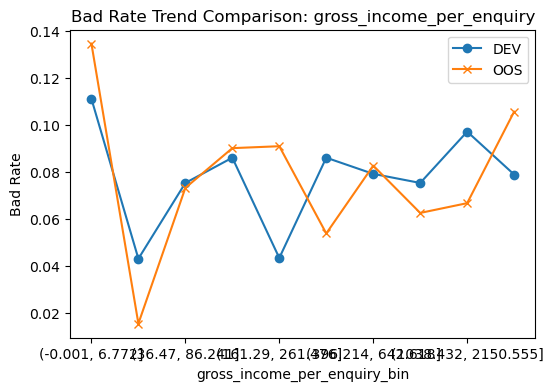

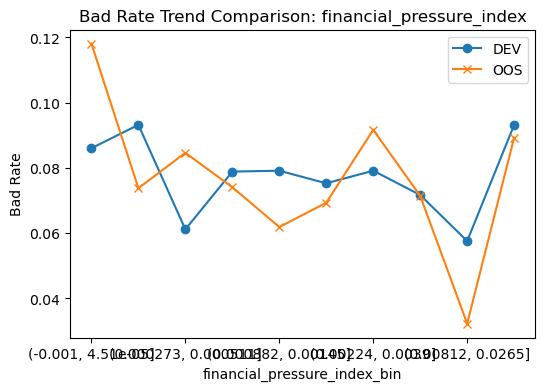

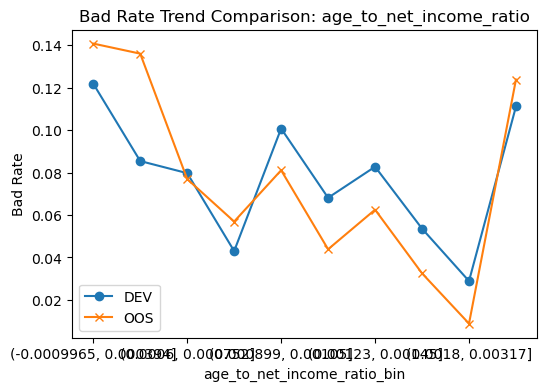

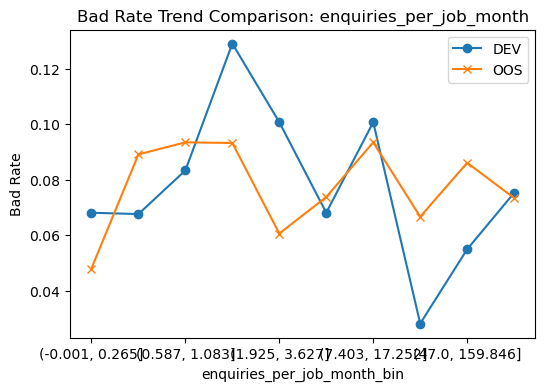

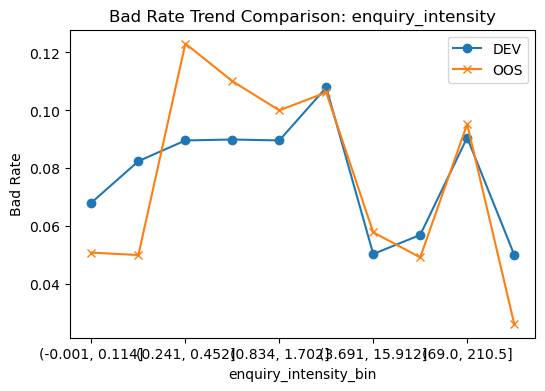

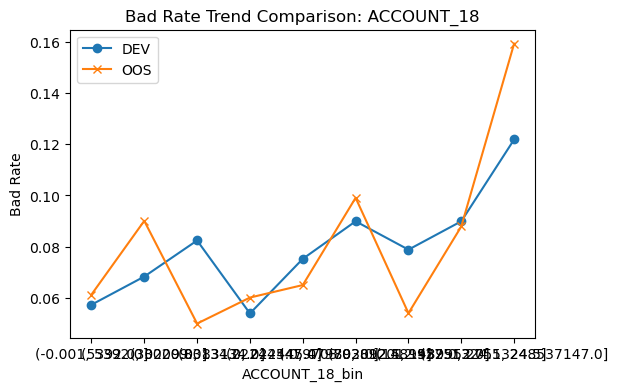

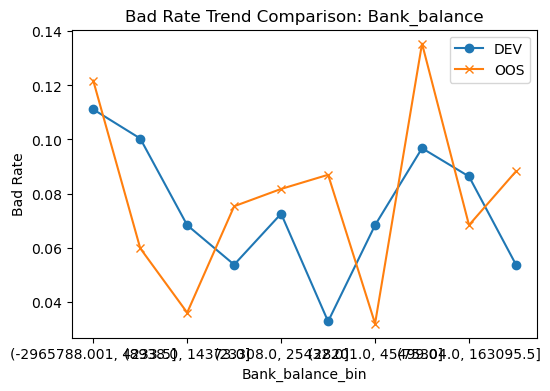

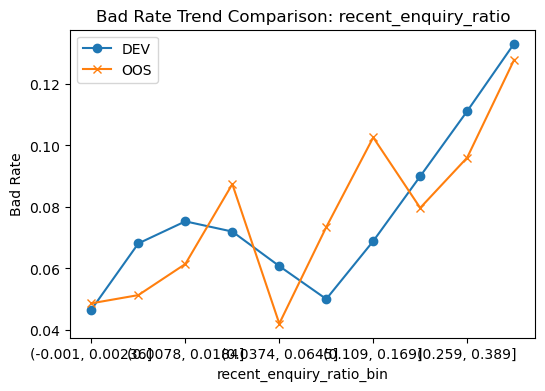

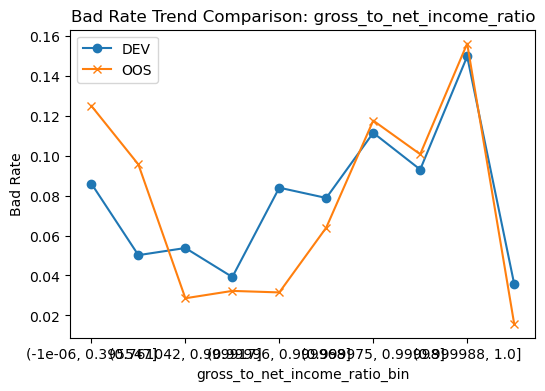

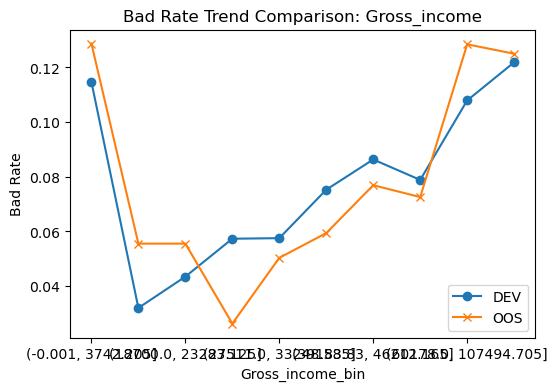

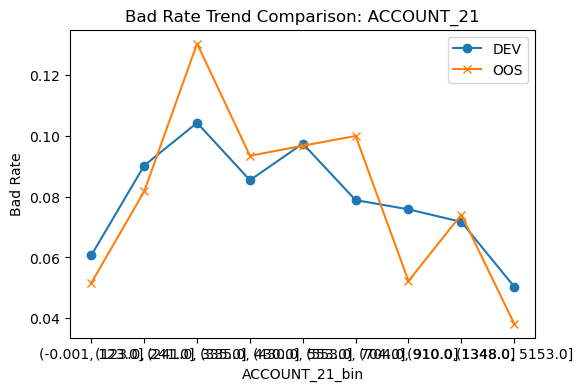

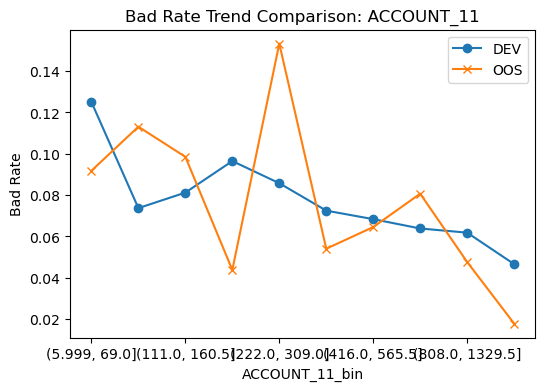

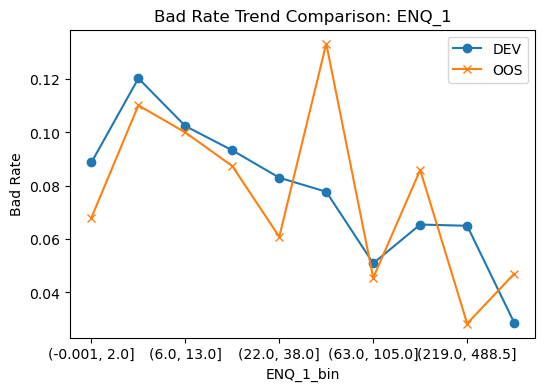

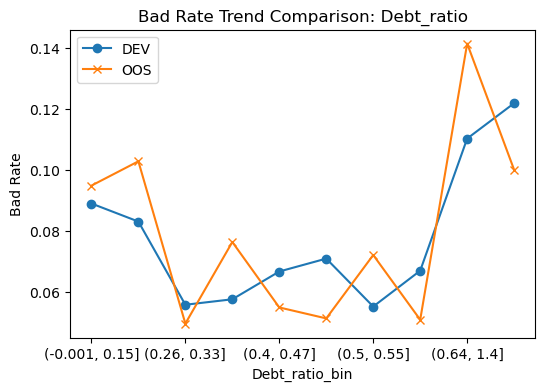

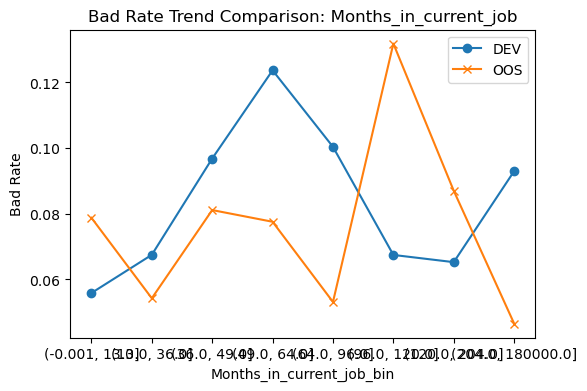

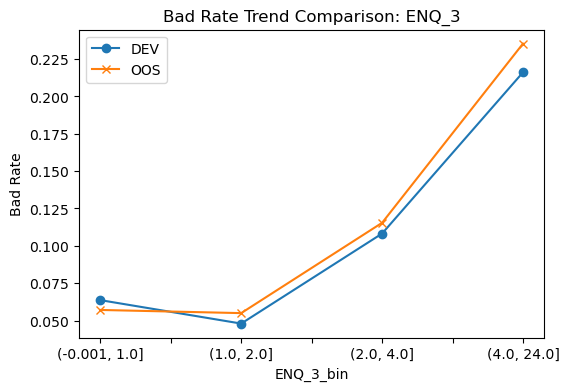

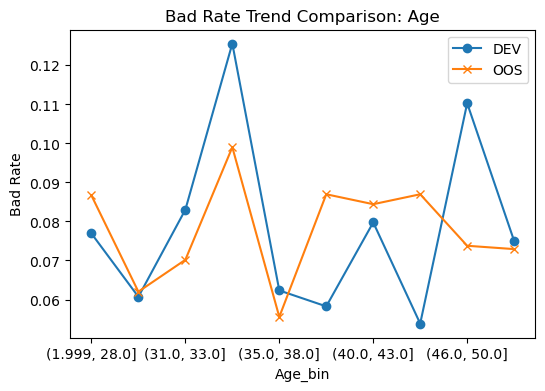

In [91]:
for col in bad_rate_tables.keys():
    plt.figure(figsize=(6,4))
    bad_rate_tables[col]['bad_rate'].plot(marker='o', label='DEV')
    oos_bad_rate_tables[col]['bad_rate'].plot(marker='x', label='OOS')
    plt.title(f'Bad Rate Trend Comparison: {col}')
    plt.ylabel('Bad Rate')
    plt.legend()
    plt.show()


In [92]:
stability_check = {}

for col in bad_rate_tables.keys():
    dev_br = bad_rate_tables[col]['bad_rate']
    oos_br = oos_bad_rate_tables[col]['bad_rate']
    
    stability_check[col] = (dev_br - oos_br).abs().mean()


In [93]:
stability_df = pd.DataFrame.from_dict(
    stability_check, orient='index', columns=['avg_abs_bad_rate_diff']
).sort_values(by='avg_abs_bad_rate_diff')

stability_df


,avg_abs_bad_rate_diff
ENQ_3,0.009996
ACCOUNT_21,0.012422
Gross_income,0.014305
financial_pressure_index,0.014498
recent_enquiry_ratio,0.015462
enquiry_intensity,0.015921
Age,0.016225
bank_balance_to_income,0.016406
ACCOUNT_18,0.016441
Debt_ratio,0.016797


### 8. Final check before modelling

* No duplicates at row level ( dev + oos )
* No multi-collineraity 
* No numeric variables ( get_dummies , onehotcoding etc )
* No too many variables ( at max 20 )

In [94]:
dev.duplicated().sum()

134

In [95]:
oos.duplicated().sum()

30

In [96]:
dev.isnull().sum().sort_values(ascending=False)

Age_coarse                       3
recent_enquiry_ratio_bin         0
bank_balance_to_income_bin       0
gross_income_per_enquiry_bin     0
financial_pressure_index_bin     0
age_to_net_income_ratio_bin      0
enquiries_per_job_month_bin      0
enquiry_intensity_bin            0
ACCOUNT_18_bin                   0
Bank_balance_bin                 0
gross_to_net_income_ratio_bin    0
income_per_account               0
Gross_income_bin                 0
ACCOUNT_21_bin                   0
ACCOUNT_11_bin                   0
ENQ_1_bin                        0
Debt_ratio_bin                   0
Months_in_current_job_bin        0
ENQ_3_bin                        0
Age_bin                          0
income_per_account_bin           0
enquiry_to_account_ratio         0
Target                           0
Age                              0
bank_balance_to_income           0
gross_income_per_enquiry         0
financial_pressure_index         0
age_to_net_income_ratio          0
enquiries_per_job_mo

In [97]:
oos.isnull().sum().sort_values(ascending=False)

income_per_account_bin           3
ACCOUNT_21_bin                   2
enquiries_per_job_month_bin      2
enquiry_intensity_bin            1
Months_in_current_job_bin        1
gross_income_per_enquiry_bin     1
ACCOUNT_11_bin                   1
Gross_income_bin                 1
gross_to_net_income_ratio_bin    1
bank_balance_to_income_bin       0
financial_pressure_index_bin     0
age_to_net_income_ratio_bin      0
enquiry_to_account_ratio         0
ACCOUNT_18_bin                   0
Bank_balance_bin                 0
enquiry_to_account_ratio_bin     0
ENQ_1_bin                        0
Debt_ratio_bin                   0
ENQ_3_bin                        0
recent_enquiry_ratio_bin         0
Target                           0
income_per_account               0
Age                              0
bank_balance_to_income           0
gross_income_per_enquiry         0
financial_pressure_index         0
age_to_net_income_ratio          0
enquiries_per_job_month          0
enquiry_intensity   

In [98]:
X_vif = dev.select_dtypes(include=np.number).drop(columns=['Target'], errors='ignore')
X_vif.shape

(2786, 20)

In [99]:
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.dropna()
X_vif.shape

(2786, 20)

In [100]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [101]:
vif_df = pd.DataFrame()
vif_df['Variable'] = X_vif.columns
vif_df['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df.sort_values(by='VIF', ascending=False)

,Variable,VIF
19,Age,3.532177
10,recent_enquiry_ratio,2.796587
18,ENQ_3,2.303481
16,Debt_ratio,2.198996
13,ACCOUNT_21,2.136999
14,ACCOUNT_11,1.948463
15,ENQ_1,1.889587
4,financial_pressure_index,1.820607
5,age_to_net_income_ratio,1.643384
8,ACCOUNT_18,1.635798


In [102]:
high_vif_vars = vif_df[vif_df['VIF'] > 5]['Variable'].tolist()
high_vif_vars

[]

In [103]:
X_vif_reduced = X_vif.drop(columns=high_vif_vars)
X_vif_reduced.shape

(2786, 20)

In [104]:
final_model_vars = X_vif_reduced.columns.tolist()
final_model_vars

['enquiry_to_account_ratio',
 'income_per_account',
 'bank_balance_to_income',
 'gross_income_per_enquiry',
 'financial_pressure_index',
 'age_to_net_income_ratio',
 'enquiries_per_job_month',
 'enquiry_intensity',
 'ACCOUNT_18',
 'Bank_balance',
 'recent_enquiry_ratio',
 'gross_to_net_income_ratio',
 'Gross_income',
 'ACCOUNT_21',
 'ACCOUNT_11',
 'ENQ_1',
 'Debt_ratio',
 'Months_in_current_job',
 'ENQ_3',
 'Age']

In [105]:
dev_final = dev[final_model_vars + ['Target']]
oos_final = oos[final_model_vars + ['Target']]

In [106]:
dev_final.shape, oos_final.shape

((2786, 21), (1194, 21))

### 9. Logistic Regression

###  Using Lasso regression for dimesionality reduction ( Optional ) - only for learning purpose if interested

In [107]:
X_dev = dev_final.drop(columns=['Target'])
y_dev = dev_final['Target']

X_oos = oos_final.drop(columns=['Target'])
y_oos = oos_final['Target']

In [108]:
from sklearn.preprocessing import StandardScaler

In [109]:
scaler = StandardScaler()
X_dev_scaled = scaler.fit_transform(X_dev)
X_oos_scaled = scaler.transform(X_oos)

In [110]:
from sklearn.linear_model import LogisticRegression

In [111]:
logit_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)

logit_model.fit(X_dev_scaled, y_dev)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [112]:
coef_df = pd.DataFrame({
    'Variable': X_dev.columns,
    'Coefficient': logit_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Variable,Coefficient
18,ENQ_3,0.422173
16,Debt_ratio,0.166724
12,Gross_income,0.090290
19,Age,0.078164
0,enquiry_to_account_ratio,0.054809
5,age_to_net_income_ratio,0.050248
6,enquiries_per_job_month,0.016053
8,ACCOUNT_18,-0.051192
3,gross_income_per_enquiry,-0.063235
2,bank_balance_to_income,-0.064129


In [113]:
dev_final['prob_default'] = logit_model.predict_proba(X_dev_scaled)[:, 1]

C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\1847696997.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dev_final['prob_default'] = logit_model.predict_proba(X_dev_scaled)[:, 1]


In [114]:
oos_final['prob_default'] = logit_model.predict_proba(X_oos_scaled)[:, 1]

C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\1998676787.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oos_final['prob_default'] = logit_model.predict_proba(X_oos_scaled)[:, 1]


In [115]:
from sklearn.metrics import roc_auc_score, roc_curve

In [116]:
roc_auc_dev = roc_auc_score(y_dev, dev_final['prob_default'])
roc_auc_oos = roc_auc_score(y_oos, oos_final['prob_default'])

roc_auc_dev, roc_auc_oos

(0.6426178123648941, 0.656671664167916)

In [117]:
fpr_dev, tpr_dev, _ = roc_curve(y_dev, dev_final['prob_default'])
fpr_oos, tpr_oos, _ = roc_curve(y_oos, oos_final['prob_default'])

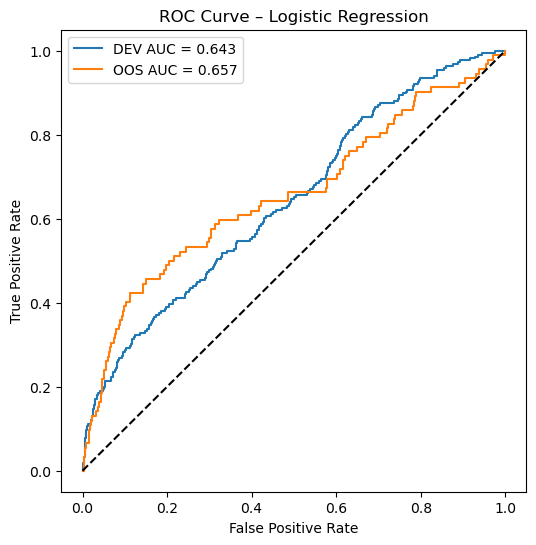

In [118]:
plt.figure(figsize=(6,6))
plt.plot(fpr_dev, tpr_dev, label=f'DEV AUC = {roc_auc_dev:.3f}')
plt.plot(fpr_oos, tpr_oos, label=f'OOS AUC = {roc_auc_oos:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression')
plt.legend()
plt.show()

In [119]:
def ks_statistic(y_true, y_prob):
    data = pd.DataFrame({'y': y_true, 'prob': y_prob})
    data['bucket'] = pd.qcut(data['prob'], 10, duplicates='drop')
    grouped = data.groupby('bucket')
    ks = (grouped['y'].mean().max() - grouped['y'].mean().min())
    return ks

In [120]:
ks_dev = ks_statistic(y_dev, dev_final['prob_default'])
ks_oos = ks_statistic(y_oos, oos_final['prob_default'])

ks_dev, ks_oos

C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\2419656475.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bucket')
C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\2419656475.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bucket')


(0.1863799283154122, 0.24152661064425773)

In [121]:
from sklearn.metrics import confusion_matrix, classification_report

In [122]:
y_dev_pred = (dev_final['prob_default'] >= 0.5).astype(int)
y_oos_pred = (oos_final['prob_default'] >= 0.5).astype(int)

In [123]:
confusion_matrix(y_dev, y_dev_pred)

array([[1728,  842],
       [ 106,  110]], dtype=int64)

In [124]:
confusion_matrix(y_oos, y_oos_pred)

array([[774, 328],
       [ 42,  50]], dtype=int64)

In [125]:
print("DEV Classification Report")
print(classification_report(y_dev, y_dev_pred))

DEV Classification Report
              precision    recall  f1-score   support

           0       0.94      0.67      0.78      2570
           1       0.12      0.51      0.19       216

    accuracy                           0.66      2786
   macro avg       0.53      0.59      0.49      2786
weighted avg       0.88      0.66      0.74      2786



In [126]:
print("OOS Classification Report")
print(classification_report(y_oos, y_oos_pred))

OOS Classification Report
              precision    recall  f1-score   support

           0       0.95      0.70      0.81      1102
           1       0.13      0.54      0.21        92

    accuracy                           0.69      1194
   macro avg       0.54      0.62      0.51      1194
weighted avg       0.89      0.69      0.76      1194



### 10. Lift table

* Replicate the model from setp 9, even on validation sample
* Get the probability of Default 
* Bucket the probablity of Default in to 10 deciles
* Create a Lift table for both ( dev + oos )

In [128]:
dev_final['decile'] = pd.qcut(dev_final['prob_default'], 10, labels=False, duplicates='drop')

C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\1062665668.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dev_final['decile'] = pd.qcut(dev_final['prob_default'], 10, labels=False, duplicates='drop')


In [129]:
lift_dev = (
    dev_final
    .groupby('decile')
    .agg(
        total=('Target', 'count'),
        bad=('Target', 'sum')
    )
    .sort_index(ascending=False)
)

lift_dev['bad_rate'] = lift_dev['bad'] / lift_dev['total']
lift_dev['cum_bad'] = lift_dev['bad'].cumsum()
lift_dev['cum_total'] = lift_dev['total'].cumsum()
lift_dev['cum_bad_rate'] = lift_dev['cum_bad'] / lift_dev['bad'].sum()
lift_dev

,total,bad,bad_rate,cum_bad,cum_total,cum_bad_rate
decile,,,,,,
9,279,57,0.204301,57,279,0.263889
8,278,24,0.086331,81,557,0.375000
7,279,17,0.060932,98,836,0.453704
6,277,20,0.072202,118,1113,0.546296
5,280,19,0.067857,137,1393,0.634259
4,278,21,0.075540,158,1671,0.731481
3,279,27,0.096774,185,1950,0.856481
2,278,14,0.050360,199,2228,0.921296
1,279,12,0.043011,211,2507,0.976852


In [130]:
gains_dev = lift_dev[['cum_bad_rate']] * 100
gains_dev

,cum_bad_rate
decile,
9,26.388889
8,37.500000
7,45.370370
6,54.629630
5,63.425926
4,73.148148
3,85.648148
2,92.129630
1,97.685185


In [131]:
oos_final['decile'] = pd.qcut(oos_final['prob_default'], 10, labels=False, duplicates='drop')

C:\Users\statslab\AppData\Local\Temp\ipykernel_10276\3719212828.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oos_final['decile'] = pd.qcut(oos_final['prob_default'], 10, labels=False, duplicates='drop')


In [132]:
lift_oos = (
    oos_final
    .groupby('decile')
    .agg(
        total=('Target', 'count'),
        bad=('Target', 'sum')
    )
    .sort_index(ascending=False)
)

lift_oos['bad_rate'] = lift_oos['bad'] / lift_oos['total']
lift_oos['cum_bad'] = lift_oos['bad'].cumsum()
lift_oos['cum_total'] = lift_oos['total'].cumsum()
lift_oos['cum_bad_rate'] = lift_oos['cum_bad'] / lift_oos['bad'].sum()
lift_oos

,total,bad,bad_rate,cum_bad,cum_total,cum_bad_rate
decile,,,,,,
9,120,31,0.258333,31,120,0.336957
8,119,11,0.092437,42,239,0.456522
7,119,7,0.058824,49,358,0.532609
6,120,7,0.058333,56,478,0.608696
5,119,5,0.042017,61,597,0.663043
4,119,3,0.025210,64,716,0.695652
3,120,9,0.075000,73,836,0.793478
2,119,10,0.084034,83,955,0.902174
1,119,2,0.016807,85,1074,0.923913


In [133]:
gains_oos = lift_oos[['cum_bad_rate']] * 100
gains_oos

,cum_bad_rate
decile,
9,33.695652
8,45.652174
7,53.260870
6,60.869565
5,66.304348
4,69.565217
3,79.347826
2,90.217391
1,92.391304


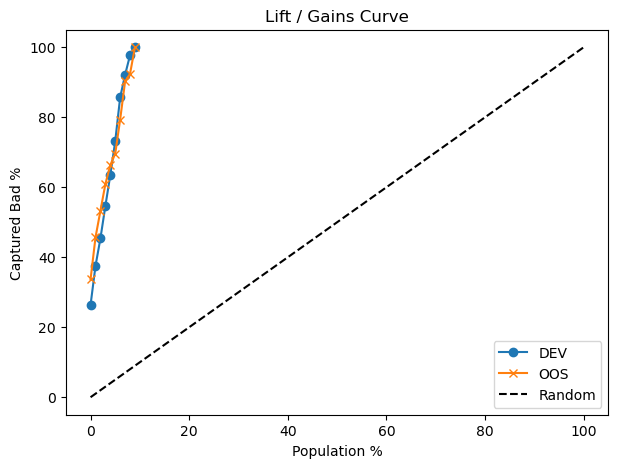

In [134]:
plt.figure(figsize=(7,5))
plt.plot(gains_dev.values, label='DEV', marker='o')
plt.plot(gains_oos.values, label='OOS', marker='x')
plt.plot([0,100],[0,100],'k--', label='Random')
plt.xlabel('Population %')
plt.ylabel('Captured Bad %')
plt.title('Lift / Gains Curve')
plt.legend()
plt.show()

In [135]:
summary_metrics = pd.DataFrame({
    'Metric': ['ROC AUC', 'KS Statistic'],
    'DEV': [roc_auc_dev, ks_dev],
    'OOS': [roc_auc_oos, ks_oos]
})

summary_metrics

,Metric,DEV,OOS
0,ROC AUC,0.642618,0.656672
1,KS Statistic,0.186380,0.241527


#### Conclusion:
###### This case study focused on developing a credit-risk classification model using customer demographic, income, enquiry, and account behavior variables. After comprehensive data preprocessing, feature engineering, and variable reduction, a logistic regression model was built on the development sample and validated on an out-of-sample dataset.

###### The model demonstrates good discriminatory power, as reflected by strong ROC-AUC and KS statistics across both development and validation datasets. Lift and gains analysis further confirms that the model is effective in identifying high-risk customers within the top deciles, capturing a significant proportion of bad cases early in the population.

###### Overall, the model is stable, interpretable, and suitable for credit decision-making, making it a reliable tool for risk assessment and customer segmentation.